<a href="https://colab.research.google.com/github/Jennguyen106/P2P-Lending-Customer-Insight-Analysis/blob/main/TIMA_Project_V%E1%BA%ADn_h%C3%A0nh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TIMA PROJECT - DATA CLEANING
- Nguyễn Thị Hải Yến

CHUẨN BỊ - THƯ VIỆN 3 HÀM DÙNG CHUNG

In [ ]:
# ===== Kết nối Google Drive =====
from google.colab import drive
drive.mount('/content/drive')

# ===== Thư viện =====
import pandas as pd
import numpy as np
import os

# ===== Hiển thị =====
pd.set_option("display.max_columns", 60) # Hiển thị tất cả các cột
pd.set_option("display.width", 200)

# ===== Hằng số của dự án =====
THU_MUC = "/content/drive/MyDrive/TIMA Analysis Project/"
DUONG_DAN = THU_MUC + "Tima raw.xlsx"

print(os.path.exists(DUONG_DAN))           # phải ra True mới chạy tiếp

Mounted at /content/drive
True


In [ ]:
# ============ 3 HÀM DÙNG CHUNG CHO CẢ NOTEBOOK ============

CLEANING_LOG = []   # nhật ký làm sạch
QC = []             # kết quả nghiệm thu


def ghi_log(giai_doan, cot, van_de, hanh_dong, so_dong, can_cu=""):
    """Ghi lại MỌI thay đổi. Gọi hàm này mỗi lần chạm vào dữ liệu."""
    CLEANING_LOG.append({
        "giai_doan": giai_doan,
        "cot": cot,
        "van_de": van_de,
        "hanh_dong": hanh_dong,          # 'Sửa' | 'Đưa về NA' | 'Gắn cờ'
        "so_dong": so_dong,
        "can_cu": can_cu,
    })
    print(f"[{giai_doan}] {cot} — {hanh_dong} {so_dong} dòng ({van_de})")


def gan_co(df, ten_co, dieu_kien, mo_ta):
    """Không sửa dữ liệu, chỉ đánh dấu để nghiệp vụ quyết sau."""
    df[ten_co] = dieu_kien.fillna(False).astype(bool)
    n = int(df[ten_co].sum())
    ghi_log("GĐ4/5", ten_co, mo_ta, "Gắn cờ", n, "chờ xác nhận nghiệp vụ")
    return df


def qc(ten_kiem_tra, dieu_kien, chi_tiet=""):
    """Chạy HẾT mọi kiểm tra, không dừng ở lỗi đầu tiên."""
    QC.append({
        "kiem_tra": ten_kiem_tra,
        "ket_qua": "PASS" if bool(dieu_kien) else "FAIL",
        "chi_tiet": str(chi_tiet),
    })

print("Đã nạp 3 hàm: ghi_log() / gan_co() / qc()")

Đã nạp 3 hàm: ghi_log() / gan_co() / qc()


---
#GIAI ĐOẠN 0 - Chụp ảnh dữ liệu
- Chưa sửa gì cả. Mục tiêu là có được danh sách toàn bộ vấn đề để xử lý theo danh sách

In [ ]:
df_raw = pd.read_excel(DUONG_DAN)
df = df_raw.copy()          # luôn làm việc trên bản sao
print(f"{df.shape[0]} dòng x {df.shape[1]} cột")

2383 dòng x 49 cột


In [ ]:
# Hồ sơ toàn bộ các cột: kiểu, %thiếu, số giá trị unique, giá trị mẫu
ho_so = pd.DataFrame({
    "kieu":       df.dtypes.astype(str),
    "so_thieu":   df.isna().sum(),
    "pct_thieu":  (df.isna().mean() * 100).round(1),
    "n_unique":   df.nunique(dropna=True),
    "gia_tri_mau": [" | ".join(str(v)[:25] for v in df[c].dropna().unique()[:3])
                    for c in df.columns],
})
ho_so

,kieu,so_thieu,pct_thieu,n_unique,gia_tri_mau
STT,object,0,0.0,2383,2 | 3 | 4
SoTienDKVayBanDau,float64,1,0.0,55,10000000.0 | 5000000.0 | 7000000.0
TienGiaiNgan,float64,1,0.0,58,250000.0 | 5000000.0 | 10000000.0
SoTienConLai,int64,0,0.0,276,0 | -50000 | 10000000
application_date,object,0,0.0,665,2023-02-30 | 2016-07-28 00:00:00 | 2016-06-29 ...
TS_CREDIT_SCORE_V2,int64,0,0.0,432,403 | 531 | 588
Số điện thoại khách hàng,object,0,0.0,1864,977966899 | 397511119 | abc1234567
FromDate,datetime64[ns],0,0.0,665,2016-06-24 00:00:00 | 2016-07-28 00:00:00 | 20...
ID,int64,0,0.0,2383,40 | 226 | 45
LoanID,int64,0,0.0,2383,16104 | 20871 | 17049


In [ ]:
# Các cột thiếu nặng (>20%) — cần quyết định chiến lược, KHÔNG bỏ qua
ho_so[ho_so["pct_thieu"] > 20].sort_values("pct_thieu", ascending=False)

,kieu,so_thieu,pct_thieu,n_unique,gia_tri_mau
ReceiveYourIncomeSalary,object,1943,81.5,5,Chuyển khoản ngân hàng | Tiền mặt và không có ...
WardName,object,1716,72.0,225,Tân Triều | Phúc Xá | Xuân Phương
CityCompany,object,610,25.6,11,Hà Nội | Hồ Chí Minh | Bắc Ninh
DescriptionPositionJob,object,482,20.2,1618,làm được hơn 3 tháng - bộ | shipper - shop ruộ...


In [ ]:
DONG_NGHI_NGO = [16104, 20871, 17049, 17067]   # LoanID
df[df["LoanID"].isin(DONG_NGHI_NGO)].T   # .T = xoay ngang cho dễ đọc 49 cột

,0,1,2,3
STT,2,3,4,5
SoTienDKVayBanDau,10000000.0,NaN,5000000.0,10000000.0
TienGiaiNgan,NaN,250000.0,5000000.0,10000000.0
SoTienConLai,0,0,-50000,0
application_date,2023-02-30,2016-07-28 00:00:00,2016-06-29 00:00:00,2016-06-29 00:00:00
TS_CREDIT_SCORE_V2,403,403,531,588
Số điện thoại khách hàng,977966899,977966899,397511119,abc1234567
FromDate,2016-06-24 00:00:00,2016-07-28 00:00:00,2016-06-29 00:00:00,2016-06-29 00:00:00
ID,40,226,45,48
LoanID,16104,20871,17049,17067


In [ ]:
# ===== Danh sách 24 vấn đề phát hiện ở GĐ0 =====
# Nhóm A = bằng chứng đã đủ, làm luôn
# Nhóm B = cần điều tra trước khi quyết định
# Nhóm C = không tự quyết được, phải hỏi nghiệp vụ

VAN_DE_GD0 = [
    # (cột, vấn đề, giai đoạn xử lý, nhóm)
    ("SoTienDKVayBanDau / Số tiền đăng ký vay ban đầu", "Cặp cột trùng, bản đầu thiếu 1 dòng", 1, "A"),
    ("TienGiaiNgan / Tiền giải ngân", "Cặp cột trùng, lệch 2 dòng", 1, "A"),
    ("SoTienConLai / Tiền gốc còn lại", "Lệch 1.674 dòng → KHÔNG phải cột trùng", 1, "B"),
    ("application_date / FromDate", "Trùng nhau hoàn toàn, cần chốt 1 trục thời gian", 1, "A"),
    ("NumberOfLoans", "Sentinel -1 (480 dòng)", 2, "A"),
    ("Thời gian đã sống", "Sentinel -1", 2, "A"),
    ("Brieft", "Chứa lý do thiếu CIC (notfound / cb1-3 / Ncy)", 2, "A"),
    ("application_date, Salary, STT", "Sai kiểu dữ liệu (object thay vì date/số)", 2, "A"),
    ("Gender", "3 nhãn lẫn lộn: 0, 1, Male", 3, "B"),
    ("Trạng thái", "4 nhãn, 'Đang vay xong' chỉ xuất hiện 1 lần", 3, "B"),
    ("Thời gian đã sống", "8 nhãn, 3 nhãn chồng lấn dưới 1 năm", 3, "A"),
    ("Salary", "Lẫn chữ và đơn vị: 'Ten thousand', '1000$'", 3, "A"),
    ("SoTienConLai", "Có giá trị âm (-50.000)", 4, "A"),
    ("LongestOverdue", "49 dòng âm → gắn cờ", 4, "C"),
    ("Birthday", "2025-01-01 → tuổi âm tại thời điểm vay", 4, "A"),
    ("Số điện thoại khách hàng", "'abc1234567' lẫn chữ", 4, "A"),
    ("FullName", "'12345' tên là chữ số", 4, "A"),
    ("ProductCreditName", "Thiếu 1 dòng", 4, "A"),
    ("Tiền giải ngân", "Ngoại lệ 1,6 tỷ (trung vị 8 triệu) → gắn cờ", 4, "A"),
    ("4 cột thiếu >20%", "ReceiveYourIncomeSalary 81,5% / WardName 72% / CityCompany 25,6% / DescriptionPositionJob 20,2%", 4, "A"),
    ("SoTienConLai vs Tiền giải ngân", "3 dòng dư nợ > số đã giải ngân", 5, "B"),
    ("HasLatePayment vs LongestOverdue", "1.565 dòng mâu thuẫn (65%)", 5, "B"),
    ("CheckTime vs FromDate", "Tra cứu CIC sau khi vay → data leakage", 5, "A"),
    ("CardNumber", "Mất số 0 đầu (int64), 20 mã gắn nhiều tên", 5, "B"),
]

NHOM = {"A": "A – Làm luôn", "B": "B – Cần điều tra", "C": "C – Hỏi nghiệp vụ"}

van_de = pd.DataFrame(VAN_DE_GD0, columns=["cot", "van_de", "giai_doan", "nhom"])
van_de.insert(0, "stt", range(1, len(van_de) + 1))
van_de["nhom"] = van_de["nhom"].map(NHOM)

print(van_de["nhom"].value_counts().to_string())
van_de

nhom
A – Làm luôn         17
B – Cần điều tra      6
C – Hỏi nghiệp vụ     1


,stt,cot,van_de,giai_doan,nhom
0,1,SoTienDKVayBanDau / Số tiền đăng ký vay ban đầu,"Cặp cột trùng, bản đầu thiếu 1 dòng",1,A – Làm luôn
1,2,TienGiaiNgan / Tiền giải ngân,"Cặp cột trùng, lệch 2 dòng",1,A – Làm luôn
2,3,SoTienConLai / Tiền gốc còn lại,Lệch 1.674 dòng → KHÔNG phải cột trùng,1,B – Cần điều tra
3,4,application_date / FromDate,"Trùng nhau hoàn toàn, cần chốt 1 trục thời gian",1,A – Làm luôn
4,5,NumberOfLoans,Sentinel -1 (480 dòng),2,A – Làm luôn
5,6,Thời gian đã sống,Sentinel -1,2,A – Làm luôn
6,7,Brieft,Chứa lý do thiếu CIC (notfound / cb1-3 / Ncy),2,A – Làm luôn
7,8,"application_date, Salary, STT",Sai kiểu dữ liệu (object thay vì date/số),2,A – Làm luôn
8,9,Gender,"3 nhãn lẫn lộn: 0, 1, Male",3,B – Cần điều tra
9,10,Trạng thái,"4 nhãn, 'Đang vay xong' chỉ xuất hiện 1 lần",3,B – Cần điều tra


---
#GIAI ĐOẠN 1 : Cấu trúc bảng
- Phạm vi : cấp dòng và cấp cột. Chưa đụng tới giá trị . Làm đầu tiên vì nó thay đổi hình dạng bảng - nếu để cuối mọi việc phía trước phải làm lại

1.1 Khóa chính và dòng trùng

In [ ]:
print("Dòng trùng hoàn toàn:", df.duplicated().sum())
print("LoanID trùng:", df["LoanID"].duplicated().sum())
print("ID trùng:", df["ID"].duplicated().sum())

# CHÚ Ý: CardNumber trùng KHÔNG phải lỗi — là khách vay nhiều lần
print("\nSố khách (CardNumber) duy nhất:", df["CardNumber"].nunique(), "trên", len(df), "khoản vay")

Dòng trùng hoàn toàn: 0
LoanID trùng: 0
ID trùng: 0

Số khách (CardNumber) duy nhất: 1868 trên 2383 khoản vay


1.2 Các cặp cột nghi trùng lặp


In [ ]:
CAP_NGHI_TRUNG = [
    ("SoTienDKVayBanDau", "Số tiền đăng ký vay ban đầu"),
    ("TienGiaiNgan",      "Tiền giải ngân"),
    ("SoTienConLai",      "Tiền gốc còn lại"),
]

for a, b in CAP_NGHI_TRUNG:
    lech = (df[a] != df[b]) & ~(df[a].isna() & df[b].isna())
    print(f"{a} vs {b}: lệch {lech.sum()} dòng")

SoTienDKVayBanDau vs Số tiền đăng ký vay ban đầu: lệch 1 dòng
TienGiaiNgan vs Tiền giải ngân: lệch 2 dòng
SoTienConLai vs Tiền gốc còn lại: lệch 1674 dòng


In [ ]:
# Xem chi tiết dòng lệch của cặp trùng TienGiaiNgan và Tiền giải ngân
lech1 = (df["TienGiaiNgan"] != df["Tiền giải ngân"]) & df["TienGiaiNgan"].notna()
df.loc[lech, ["LoanID", "Trạng thái", "TienGiaiNgan", "Tiền giải ngân",
             "Số tiền đăng ký vay ban đầu", "SoTienConLai"]]

,LoanID,Trạng thái,TienGiaiNgan,Tiền giải ngân,Số tiền đăng ký vay ban đầu,SoTienConLai
0,16104,Đang vay xong,NaN,10000000,10000000,0
2,17049,Kết thúc,5000000.0,5000000,5000000,-50000
3,17067,Kết thúc,10000000.0,10000000,10000000,0
5,17084,Kết thúc,10000000.0,10000000,10000000,0
6,17984,Kết thúc,7000000.0,7000000,7000000,0
...,...,...,...,...,...,...
2374,56736,Kết thúc,20000000.0,20000000,20000000,0
2377,56971,Đang Vay,15000000.0,15000000,15000000,14254750
2378,56967,Đang Vay,5000000.0,5000000,5000000,3474831
2380,57212,Kết thúc,6000000.0,6000000,6000000,0


Nhận xét:
- Tiền giải ngân = 10000000 , Số tiền đăng kí vay ban đầu = 10000000, SoTienConLai = 0 ( khách hàng đã thanh toán hết ) như vậy TienGiaiNgan là con số sai (Logic: một khoản vay đăng ký 10 triệu, được giải ngân đúng 10 triệu, sau đó khách trả hết nên dư nợ về 0 và trạng thái chuyển "Kết thúc" — đây là một chuỗi sự kiện hoàn toàn nhất quán)

- Kết luận và hành động : Tiền giải ngân (10000000) là con số đúng , TienGiaiNgan (250000) là lỗi dữ liệu --> giữ lại cột Tiền giải ngân và bỏ cột TienGiaiNgan

In [ ]:
# Xem chi tiết cặp trùng 2 SoTienDKVayBanDau và Số tiền đăng kí vay ban đầu
lech2 = (df["SoTienDKVayBanDau"] != df["Số tiền đăng ký vay ban đầu"])
df.loc[lech2, ["LoanID", "Trạng thái", "TienGiaiNgan", "Tiền giải ngân",
             "Số tiền đăng ký vay ban đầu", "SoTienConLai","SoTienDKVayBanDau"]]

,LoanID,Trạng thái,TienGiaiNgan,Tiền giải ngân,Số tiền đăng ký vay ban đầu,SoTienConLai,SoTienDKVayBanDau
1,20871,Kết thúc,250000.0,10000000,10000000,0,NaN


Nhận xét :
- SoTienDKVayBanDau và Số tiền đăng ký vay ban đầu lệch một dòng và ở cột SoTienDKVayBanDau là NaN và Số tiền đăng ký vay ban đầu là 10000000 nên cột Số tiền đăng ký van ban đầu đầy đủ hơn --> hành động : giữ lại cột Số tiền đăng ký vay ban đầu và xóa cột SoTienDKVayBanDau.

In [ ]:
#Xem chi tiết nội dung cặp cột trùng SoTienConLai và Tiền gốc còn lại

In [ ]:
lech3 = (df["SoTienConLai"] != df["Tiền gốc còn lại"])
df.loc[lech3, ["LoanID", "Trạng thái", "TienGiaiNgan", "Tiền giải ngân",
             "Số tiền đăng ký vay ban đầu", "SoTienConLai","Tiền gốc còn lại"]]

,LoanID,Trạng thái,TienGiaiNgan,Tiền giải ngân,Số tiền đăng ký vay ban đầu,SoTienConLai,Tiền gốc còn lại
0,16104,Đang vay xong,NaN,10000000,10000000,0,10000000
2,17049,Kết thúc,5000000.0,5000000,5000000,-50000,5000000
3,17067,Kết thúc,10000000.0,10000000,10000000,0,10000000
5,17084,Kết thúc,10000000.0,10000000,10000000,0,10000000
6,17984,Kết thúc,7000000.0,7000000,7000000,0,4000000
...,...,...,...,...,...,...,...
2374,56736,Kết thúc,20000000.0,20000000,20000000,0,13899322
2377,56971,Đang Vay,15000000.0,15000000,15000000,14254750,13441422
2378,56967,Đang Vay,5000000.0,5000000,5000000,3474831,1814424
2380,57212,Kết thúc,6000000.0,6000000,6000000,0,6000000


In [ ]:
# Cặp cột trên lệch rất nhiều 1674 dòng , kiểm tra logic nghiệp vụ để biết cột nào là dư nợ hiện tại
# khoản "Kết thúc" thì dư nợ LẼ RA phải = 0. Cột nào thoả điều đó nhiều hơn?
for cot in ["SoTienConLai", "Tiền gốc còn lại"]:
     ty_le = (df.loc[df["Trạng thái"] == "Kết thúc", cot] == 0).mean() * 100
     print(f"{cot}: {ty_le:.1f}% khoản Kết thúc có giá trị 0")

SoTienConLai: 93.3% khoản Kết thúc có giá trị 0
Tiền gốc còn lại: 3.8% khoản Kết thúc có giá trị 0


Nhận xét:
- Theo logic thì các khoản vay đã Kết thúc thì dư nợ hay tiền gốc còn lại phải về 0 . Cột SoTienConLai có 93.3% khoản Kết thúc có giá trị 0 còn cột Tiền gốc còn lại chỉ có 3.8% khoản Kết thúc có giá trị 0. Cột SoTienConLai thỏa mãn điều kiện trên nhiều hơn
- Kết luận và hành động : Cột Tiền gốc còn lại chưa xác định là gì ,cần hỏi nghiệp vụ và quyết định sau --> Hành động:  Gắn cờ cho cột Tiền gốc còn lại - hai cột Tiền gốc còn lại và SoTienConLai có nội dung trong từ điển giống nhau nhưng lệch nhiều --> hỏi nghiệp vụ cột này và đặt lại tên , giải thích lại trong từ điển

In [ ]:
# Xóa cột SoTienDKVayBanDau và TienGiaiNgan — và ghi log lý do
COT_XOA = {
    "SoTienDKVayBanDau": "trùng với 'Số tiền đăng ký vay ban đầu', bản này thiếu 1 dòng",
    "TienGiaiNgan":      "trùng với 'Tiền giải ngân', có 1 giá trị sai logic",
}

for cot, ly_do in COT_XOA.items():
    df = df.drop(columns=[cot])
    ghi_log("GĐ1", cot, "cột trùng lặp", "Sửa", 0, ly_do)

[GĐ1] SoTienDKVayBanDau — Sửa 0 dòng (cột trùng lặp)
[GĐ1] TienGiaiNgan — Sửa 0 dòng (cột trùng lặp)


In [ ]:
df = gan_co(df, "co_lech_2_cot_du_no",
            df["SoTienConLai"] != df["Tiền gốc còn lại"],
            "SoTienConLai (dư nợ hiện tại, 93,3% khoản Kết thúc = 0) khác Tiền gốc còn lại "
            "(3,8%) — 2 khái niệm khác nhau nhưng từ điển ghi giống nhau, cần nghiệp vụ đặt lại tên")

[GĐ4/5] co_lech_2_cot_du_no — Gắn cờ 1674 dòng (SoTienConLai (dư nợ hiện tại, 93,3% khoản Kết thúc = 0) khác Tiền gốc còn lại (3,8%) — 2 khái niệm khác nhau nhưng từ điển ghi giống nhau, cần nghiệp vụ đặt lại tên)


1.3 Chốt một trục thời gian duy nhất

`application_date` và `FromDate` có thể trùng nhau hoàn toàn. Nếu đúng vậy, giữ cả hai chỉ gây
nhầm lẫn cho người dùng sau.

In [ ]:
# ép kiểu hai cột sang datetime và xem lệch nhau bao nhiêu dòng, xem dòng lệch ở đâu
ad = pd.to_datetime(df["application_date"], errors="coerce")
fd = pd.to_datetime(df["FromDate"], errors="coerce")
khac = (ad != fd) & ~(ad.isna() & fd.isna())
print(f"application_date khác FromDate: {khac.sum()} dòng")
df.loc[khac, ["LoanID", "application_date", "FromDate"]]

application_date khác FromDate: 1 dòng


/tmp/ipykernel_2535/149272072.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ad = pd.to_datetime(df["application_date"], errors="coerce")


,LoanID,application_date,FromDate
0,16104,2023-02-30,2016-06-24


Nhận xét:
- Hai cột thời gian application_date và FromDate trùng nhau ở toàn bộ dòng: dòng duy nhất lệch là do giá trị rác '2023-02-30'(ngày không tồn tại) --> Hành động : giữ FromDate và xóa application_date và ghi log
- Lưu ý cho giai đoạn phân tích: vì ngày nộp hồ sơ = ngày giải ngân, bộ dữ liệu không đo được thời gian xử lý hồ sơ. ToDate-FromDate là kỳ hạn vay, không phải tốc độ duyệt

In [ ]:
df = df.drop(columns=["application_date"])
ghi_log("GĐ1", "application_date",
        "trùng hoàn toàn với FromDate (chỉ lệch ở 1 ô rác '2023-02-30')",
        "Sửa", 0,
        "giữ FromDate vì đã đúng kiểu datetime và không chứa giá trị rác")

[GĐ1] application_date — Sửa 0 dòng (trùng hoàn toàn với FromDate (chỉ lệch ở 1 ô rác '2023-02-30'))


---
# Giai đoạn 2 — Giá trị thiếu & kiểu dữ liệu

Quy **mọi cách biểu diễn "thiếu"** về một chuẩn duy nhất là `NaN`, rồi mới ép kiểu.

Đây là giai đoạn dễ bỏ sót nhất nhưng lại quyết định độ tin cậy của tất cả giai đoạn sau:
nếu `NumberOfLoans` còn giá trị `-1`, mọi phép trung bình trên cột đó đều sai.

2.1 Sentinel - Gía trị giả danh dữ liệu thật

Sentinel value là một giá trị trông giống dữ liệu thật nhưng thực chất không phải dữ liệu, mà chỉ đóng vai trò tín hiệu: báo hiệu điểm dừng, dữ liệu thiếu, hoặc trạng thái đặc biệt.

In [ ]:
# Chuỗi rỗng / 'null' / 'NaN' → NaN thật
df = df.replace(["", "null", "NaN", "None"], np.nan)

# Sentinel số: -1 KHÔNG phải giá trị thật, là mã "không tra cứu được"
n = int((df["NumberOfLoans"] == -1).sum())
df.loc[df["NumberOfLoans"] == -1, "NumberOfLoans"] = np.nan
ghi_log("GĐ2", "NumberOfLoans", "sentinel -1", "Đưa về NA", n, "-1 = không tra cứu được CIC")

# Sentinel trong cột phân loại (lưu ý: ở đây -1 là kiểu SỐ, không phải chuỗi)
n = int((df["Thời gian đã sống"] == -1).sum())
df["Thời gian đã sống"] = df["Thời gian đã sống"].replace(-1, np.nan)
ghi_log("GĐ2", "Thời gian đã sống", "sentinel -1", "Đưa về NA", n, "-1 không phải một nhãn hợp lệ")

[GĐ2] NumberOfLoans — Đưa về NA 480 dòng (sentinel -1)
[GĐ2] Thời gian đã sống — Đưa về NA 1 dòng (sentinel -1)


2.2 Giải mã lý do thiếu
- NumberOfLoans: Số lượng khoản vay khách hàng đang có tại các TCTD ( theo data dictionary)
- 480 dòng sentinel -1 thiếu không cùng một lý do
- xem cột Brieft : Mã tóm tắt lịch sử tín dụng từ CIC ( theo data dictionary)
- Xem cột CreditInfo

In [ ]:
# Đối chiếu chéo: Brieft cho biết VÌ SAO NumberOfLoans bị thiếu
pd.crosstab(df["Brieft"], df["NumberOfLoans"].fillna("NaN"))

NumberOfLoans,0.0,1.0,2.0,3.0,4.0,5.0,6.0,NaN
Brieft,,,,,,,,
0,702,0,0,0,0,0,0,0
1,0,409,0,0,0,0,0,0
2,0,0,222,0,0,0,0,0
3,0,0,0,143,0,0,0,0
4,0,0,0,0,62,0,0,0
5,0,0,0,0,0,28,0,0
1cy,0,115,0,0,0,0,0,0
2cy,0,0,115,0,0,0,0,0
3cy,0,0,0,63,0,0,0,0


In [ ]:
df[(df["Brieft"] == "cb2") & (df["NumberOfLoans"].notna())]

,STT,SoTienConLai,TS_CREDIT_SCORE_V2,Số điện thoại khách hàng,FromDate,ID,LoanID,Số tiền đăng ký vay ban đầu,Tiền giải ngân,Tiền gốc còn lại,ToDate,Trạng thái,FullName,CardNumber,Gender,Birthday,CityName,DistrictName,WardName,Hình thức cư trú,Thời gian đã sống,Street,CityNameHouseHold,DistrictNameHouseHold,WardNameHouseHold,JobName,NameCompany,AddressCompany,CityCompany,DistrictNameCompany,Salary,ReceiveYourIncomeSalary,DescriptionPositionJob,RelativeFamilyName,FullNameFamily,ProductCreditName,InterestPaymentType,LongestOverdue,CreditInfo,Name,Address,CheckTime,Brieft,NumberOfLoans,HasBadDebt,HasLatePayment,co_lech_2_cot_du_no
2086,2698,0,579,961368858,2018-10-26,281718,54769,10000000,10000000,10000000,2019-01-25,Kết thúc,Bùi Thị Thu Hằng,15185000161,1,1985-06-13,Hà Nội,Đống Đa,Láng Thượng,Đồng sở hữu,1 - 3 năm,"Số nhà 28, Ngõ 157, Phố Chùa Láng, Phường Láng...",Hà Nội,Thạch Thất,Kim Quan,Hành chính,Trường Đại Học Lao Động - Xã Hội,"Số 43 Đường Trần Duy Hưng, Phường Trung Hòa, Q...",Hà Nội,Thạch Thất,7000000,Chuyển khoản ngân hàng,Làm nhân viên hành chính bên trung tâm xử lý n...,Chị / Em gái,NaN,Cầm cố Điện thoại,Tất toán cuối kỳ,1,Khách hàng thuộc đối tượng có mức cảnh báo CB2...,BUI THI THU HANG,TRUONG DAI HOC LAO DONG XA HOI 43 TRAN DUY HUN...,2019-03-17 13:17:32,cb2,1.0,1,0,True


In [ ]:
df[["CreditInfo","Brieft"]].value_counts()

,,count
CreditInfo,Brieft,
"Khách hàng hiện không có quan hệ tại TCTD, không có nợ cần chú ý và không có nợ xấu tại thời điểm cuối tháng 31/01/2019",0,659
"Khách hàng hiện đang quan hệ tại 1 TCTD, không có nợ cần chú ý và không có nợ xấu tại thời điểm cuối tháng 31/01/2019",1,393
Khách hàng thuộc đối tượng có mức cảnh báo CB1 tính đến ngày 31/01/2019,cb1,220
"Khách hàng hiện đang quan hệ tại 2 TCTD, không có nợ cần chú ý và không có nợ xấu tại thời điểm cuối tháng 31/01/2019",2,212
"Khách hàng hiện đang quan hệ tại 3 TCTD, không có nợ cần chú ý và không có nợ xấu tại thời điểm cuối tháng 31/01/2019",3,138
"Khách hàng hiện đang quan hệ tại 1 TCTD, có nợ cần chú ý và không có nợ xấu tại thời điểm cuối tháng 31/01/2019",1cy,115
"Khách hàng hiện đang quan hệ tại 2 TCTD, có nợ cần chú ý và không có nợ xấu tại thời điểm cuối tháng 31/01/2019",2cy,112
"Khách hàng hiện đang quan hệ tại 3 TCTD, có nợ cần chú ý và không có nợ xấu tại thời điểm cuối tháng 31/01/2019",3cy,62
"Khách hàng hiện đang quan hệ tại 4 TCTD, không có nợ cần chú ý và không có nợ xấu tại thời điểm cuối tháng 31/01/2019",4,55


Nhận xét - phát hiện ra 3 vấn đề như sau:
- Vấn đề 1: -1 gộp 3 tình huống khác nhau - 480 dòng có NumberOfLoans = -1 . Nhìn sàn Brieft mới thấy chúng chia thành : notfound(219) - CIC không tìm thấy khách -> thiếu dữ liệu thật ; cb1/cb2/cb3 (261) - CIC có trả lời nhưng trả lời là " khách này có mức cảnh báo cb" -> đây là tín hiệu rủi ro không phải thiếu dữ liệu
- Vấn đề 2: NumberOfLoans - tên và định nghĩa trong từ điển dữ liệu sai . Tên gợi ý và được định nghĩa là số khoản vay nhưng CreditInfo cho thấy nó là số tổ chức tín dụng khách đang có quan hệ . Một người có thể vay 5 khoản ở 1 ngân hàng - vấn tính là một tổ chức tín dụng
- Vấn đề 3: Hàm rút gọn của TIMA bị lỗi - có thể nhìn thấy rõ ở hai dòng chéo cuối với thông tin CreditInfo và Brieft ( "Khách hàng hiện đang quan hệ tại 7 tổ chức tín dụng ..." - "notfound" và "Khách hàng hiện đang quan hệ tại 8 tổ chức tín dụng.." -"notfound" . Nguyên nhân có thể : hàm rút gọn của TIMA chỉ xử lý đến 6 TCTD và 7,8 sẽ trả về giá trị mặc định ( trớ trêu thay hai khách này lại nằm trong nhóm khách rủi ro nhất với quan hệ với 7,8 tổ chức tín dụng )
- Kết luận và hướng giải quyết : Cách 1 : xóa hai cột được suy ra từ cột gốc CreditInfo chỉ giữ lại cột gốc cho những phân tích tiếp theo ; Cách 2 : gán cờ hai cột này cần chú ý và báo cáo cho đội xử lý hệ thống, vận hành - sửa lại cột như tên, mã hóa ,... thì mới sử dụng được ở phân tích sau --> Chọn cách 2 - gán cờ cho phần làm sạch này, xử lý sau nếu phân tích Vận hành kinh doanh của mình cần - lấy cột gốc CreditInfo để phân tích

In [ ]:
brf = df["Brieft"].astype(str)

# 1. Ghi lại VÌ SAO thiếu — 480 dòng không cùng một nguyên nhân
df["ly_do_thieu_cic"] = np.select(
    [brf == "notfound", brf.str.startswith("cb")],
    ["Không tìm thấy trên CIC", "Có cảnh báo CB"],
    default="Tra cứu thành công",
)
ghi_log("GĐ2", "ly_do_thieu_cic", "480 dòng sentinel -1 có 3 nguyên nhân khác nhau",
        "Sửa", len(df),
        "tách từ Brieft; cb1/2/3 là tín hiệu rủi ro, KHÔNG phải thiếu dữ liệu")

# 2. Cờ nợ cần chú ý — thông tin chỉ có ở Brieft
df = gan_co(df, "co_no_can_chu_y",
            brf.str.endswith("cy"),
            "CIC ghi nhận có nợ cần chú ý (hậu tố 'cy'), thông tin không có ở NumberOfLoans")

# 3. Cờ lỗi mã hoá của hệ thống nguồn
df = gan_co(df, "co_loi_ma_hoa_brieft",
            (brf == "notfound") & df["CreditInfo"].notna(),
            "Brieft='notfound' nhưng CreditInfo CÓ dữ liệu — hàm mã hoá của TIMA sai khi số TCTD > 6")

print(df["ly_do_thieu_cic"].value_counts().to_string())
df.loc[df["co_loi_ma_hoa_brieft"], ["LoanID", "Brieft", "CreditInfo"]]

[GĐ2] ly_do_thieu_cic — Sửa 2383 dòng (480 dòng sentinel -1 có 3 nguyên nhân khác nhau)
[GĐ4/5] co_no_can_chu_y — Gắn cờ 336 dòng (CIC ghi nhận có nợ cần chú ý (hậu tố 'cy'), thông tin không có ở NumberOfLoans)
[GĐ4/5] co_loi_ma_hoa_brieft — Gắn cờ 2 dòng (Brieft='notfound' nhưng CreditInfo CÓ dữ liệu — hàm mã hoá của TIMA sai khi số TCTD > 6)
ly_do_thieu_cic
Tra cứu thành công         1902
Có cảnh báo CB              262
Không tìm thấy trên CIC     219


,LoanID,Brieft,CreditInfo
248,54156,notfound,"Khách hàng hiện đang quan hệ tại 8 TCTD, có nợ..."
592,47861,notfound,"Khách hàng hiện đang quan hệ tại 7 TCTD, không..."


2.3 Ép kiểu dữ liệu

In [ ]:
COT_NGAY = ["FromDate", "ToDate", "Birthday", "CheckTime"]
for cot in COT_NGAY:
    df[cot] = pd.to_datetime(df[cot], errors="coerce")



print(df.dtypes)

STT                                    object
SoTienConLai                            int64
TS_CREDIT_SCORE_V2                      int64
Số điện thoại khách hàng               object
FromDate                       datetime64[ns]
ID                                      int64
LoanID                                  int64
Số tiền đăng ký vay ban đầu             int64
Tiền giải ngân                          int64
Tiền gốc còn lại                        int64
ToDate                         datetime64[ns]
Trạng thái                             object
FullName                               object
CardNumber                              int64
Gender                                 object
Birthday                       datetime64[ns]
CityName                               object
DistrictName                           object
WardName                               object
Hình thức cư trú                       object
Thời gian đã sống                      object
Street                            

In [ ]:
n_loi = int(pd.to_numeric(df["STT"], errors="coerce").isna().sum())
df["STT"] = pd.to_numeric(df["STT"], errors="coerce").astype("Int64")
ghi_log("GĐ2", "STT", "kiểu object dù là cột số thứ tự", "Sửa", n_loi,
        f"ép sang Int64; {n_loi} ô không ép được → NA")
print("STT dtype:", df["STT"].dtype)

[GĐ2] STT — Sửa 1 dòng (kiểu object dù là cột số thứ tự)
STT dtype: Int64


In [ ]:
# Nghiệm thu GĐ2: không còn cột SỐ nào nằm ở dạng object
COT_PHAI_LA_SO = ["Số tiền đăng ký vay ban đầu", "Tiền giải ngân",
                  "SoTienConLai", "LongestOverdue", "TS_CREDIT_SCORE_V2"]
for cot in COT_PHAI_LA_SO:
    if cot in df.columns:
        print(f"{cot}: {df[cot].dtype}")

Số tiền đăng ký vay ban đầu: int64
Tiền giải ngân: int64
SoTienConLai: int64
LongestOverdue: int64
TS_CREDIT_SCORE_V2: int64


Salary đang là object vì lẫn chữ (ten thousand, 1000$) -->  Xử lý ở GĐ3 rồi mới ép kiểu.


---
Giai đoạn 3: Chuẩn hóa dữ liệu từng cột
- Phạm vi : một cột, không nhìn sang cột khác . Gộp nhãn trùng nghĩa , thống nhất đơn vị, thống nhất mã hóa

 3.1 `Gender` — text lẫn vào cột mã số

Trước khi map `0`/`1` sang nhãn, phải **chứng minh** được chiều nào là Nam. Dùng bằng chứng nội bộ,
không đoán. Tên đệm tiếng Việt là bằng chứng mạnh trên toàn bộ 2.383 dòng.

In [ ]:
ten = df["FullName"].fillna("")
dem = np.where(ten.str.contains(r"\bVăn\b", case=False), "Văn",
       np.where(ten.str.contains(r"\bThị\b", case=False), "Thị", "khác"))
print(pd.crosstab(df["Gender"].fillna("NaN"), dem))

col_0   Thị  Văn  khác
Gender                
0        23  234  1262
1       549    4   306
Male      0    0     1
NaN       0    0     4


Nhận xét : Điều tra tên đệm sẽ thấy Male = 0, Female = 1 --> Sửa một ô lẫn Male = 0 và ghi log

In [ ]:
# 1. Sửa lỗi: text lẫn vào cột mã số
n_male = int((df["Gender"] == "Male").sum())
df["Gender"] = df["Gender"].replace("Male", 0)
ghi_log("GĐ3", "Gender", "giá trị text 'Male' lẫn trong cột mã số 0/1", "Sửa", n_male,
        "LoanID 20871 và 16104 cùng 1 khách (CardNumber 12603108): dòng ghi 0, dòng ghi 'Male'")

# 2. Đổi mã sang nhãn để không đảo nhầm khi phân tích
GENDER_MAP = {0: "Nam", 1: "Nữ"}
n_map = int(df["Gender"].notna().sum())
df["Gender"] = df["Gender"].map(GENDER_MAP)
ghi_log("GĐ3", "Gender", "mã 0/1 khó đọc, dễ đảo nhầm khi phân tích", "Sửa", n_map,
        "chiều map xác nhận 2 nguồn: cặp dòng cùng khách + tên đệm Văn/Thị")

print(df["Gender"].value_counts(dropna=False).to_string())

[GĐ3] Gender — Sửa 1 dòng (giá trị text 'Male' lẫn trong cột mã số 0/1)
[GĐ3] Gender — Sửa 2379 dòng (mã 0/1 khó đọc, dễ đảo nhầm khi phân tích)
Gender
Nam    1520
Nữ      859
NaN       4


/tmp/ipykernel_2535/1074279821.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace("Male", 0)


3.2 'Trạng thái' - nhãn lạ
- 4 nhãn , có một nhãn Đang vay xong chỉ xuất hiện một lần

In [ ]:
# Xem có bao nhiêu trạng thái
print(df["Trạng thái"].value_counts(dropna=False))

Trạng thái
Kết thúc         1586
Đang Vay          590
Nợ Xấu            206
Đang vay xong       1
Name: count, dtype: int64


In [ ]:
#Điều tra 1 dòng có nhãn lạ ' Đang vay xong' - dòng này giống nhóm nào trong 3 nhóm chính
for nhom in df['Trạng thái'].dropna().unique():
    ty_le = (df.loc[df['Trạng thái']== nhom, 'SoTienConLai']==0).mean() * 100
    print(f"{nhom}: {ty_le:.1f}% có dư nợ = 0")

Đang vay xong: 100.0% có dư nợ = 0
Kết thúc: 93.3% có dư nợ = 0
Đang Vay: 0.3% có dư nợ = 0
Nợ Xấu: 1.5% có dư nợ = 0


Nhận xét : Dư nợ của khoản vay có Trạng thái - Đang vay xong = 0 có nghĩa là khoản vay đã kết thúc --> đổi nhãn Đang vay xong sang Kết thúc

In [ ]:
 df["Trạng thái"] = df["Trạng thái"].replace({"Đang vay xong": "Kết thúc"})
 ghi_log("GĐ3", "Trạng thái", "nhãn lạ 'Đang vay xong'", "Sửa", 1, "căn cứ: SoTienConLai =0 ( dư nợ = 0 nghĩa là khoản vay đã Kết thúc)")

[GĐ3] Trạng thái — Sửa 1 dòng (nhãn lạ 'Đang vay xong')


3.3 Thời gian đã sống - 8 nhãn , phát hiện nhãn chồng lẫn cần gộp

In [ ]:
print(df['Thời gian đã sống'].value_counts(dropna=False))

Thời gian đã sống
Hơn 10 năm       1003
3 - 10 năm        531
1 - 3 năm         464
Dưới 1 năm        206
NaN               165
Dưới 6 tháng        6
6 tháng             5
Từ 7-12 tháng       3
Name: count, dtype: int64


Nhận xét:
- Ba nhãn Dưới 6 tháng, 6 tháng, Từ 7-12 tháng đều có thể gộp về nhãn Dưới 1 năm

In [ ]:
GOP_NHAN = {
    "Dưới 6 tháng":  "Dưới 1 năm",
    "6 tháng":       "Dưới 1 năm",
    "Từ 7-12 tháng": "Dưới 1 năm",
}
n = int(df["Thời gian đã sống"].isin(GOP_NHAN).sum())
df["Thời gian đã sống"] = df["Thời gian đã sống"].replace(GOP_NHAN)
ghi_log("GĐ3", "Thời gian đã sống", "3 nhãn chồng lấn dưới 1 năm", "Sửa", n,
        "có thể do 2 phiên bản form nhập liệu")

print(df["Thời gian đã sống"].value_counts(dropna=False))

[GĐ3] Thời gian đã sống — Sửa 14 dòng (3 nhãn chồng lấn dưới 1 năm)
Thời gian đã sống
Hơn 10 năm    1003
3 - 10 năm     531
1 - 3 năm      464
Dưới 1 năm     220
NaN            165
Name: count, dtype: int64


3.4 Salary - lẫn chữ và đơn vị tiền
- Nguyên tắc: giá trị nào có căn cứ có thể quy đổi được thì sửa, giá trị nào không suy ra được thì đưa về NA

In [ ]:
# Tìm mọi giá trị không ép được sang số
loi = df.loc[df["Salary"].notna() & pd.to_numeric(df["Salary"], errors="coerce").isna(), "Salary"]
print(loi.value_counts())

Salary
Ten thousand    1
1000$           1
Name: count, dtype: int64


In [ ]:
# giá trị 1000$ có thể lương của khách hàng $, nhân viên nhập nguyên theo đơn vị tiền tệ $
#-> giả định 1$ = 23000 và chuyển Salary = 1000$ sang VND
TY_GIA = 23000
df["Salary"] = df["Salary"].replace("1000$", 1000 * TY_GIA)
ghi_log("GĐ3", "Salary", "'1000$' lẫn đơn vị USD", "Sửa", 1, f"tỷ giá giả định {TY_GIA:,}")
# Gía trị Salary Ten thousand không có căn cứ xác định --> Đưa về NA
df["Salary"] = df["Salary"].replace("Ten thousand", np.nan)
ghi_log("GĐ3", "Salary", "'Ten thousand' không rõ đơn vị", "Đưa về NA", 1, "không đủ căn cứ")
# ép lại kiểu cột Salary về dạng số
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")
print(df["Salary"].dtype)

[GĐ3] Salary — Sửa 1 dòng ('1000$' lẫn đơn vị USD)
[GĐ3] Salary — Đưa về NA 1 dòng ('Ten thousand' không rõ đơn vị)
float64


/tmp/ipykernel_2535/2537155468.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Salary"] = df["Salary"].replace("Ten thousand", np.nan)


---
# Giai đoạn 4 — Kiểm tra hợp lệ trong từng cột

Vẫn **một cột**. Ba câu hỏi cho mỗi cột số: có giá trị âm ở nơi không thể âm không? có giá trị
ngoài khoảng hợp lý không? có định dạng rác không?

Nhớ nguyên tắc: **không tự sửa thành 0 hay trị tuyệt đối** — cái đó là suy diễn. Không suy ra được
thì gắn cờ.

### 4.1 Giá trị âm ở nơi không thể âm

In [ ]:
for cot in ["SoTienConLai", "Tiền giải ngân", "Số tiền đăng ký vay ban đầu", "LongestOverdue"]:
    if cot in df.columns:
        print(f"{cot}: {(df[cot] < 0).sum()} dòng âm, min = {df[cot].min():,.0f}")

SoTienConLai: 1 dòng âm, min = -50,000
Tiền giải ngân: 0 dòng âm, min = 1,000,000
Số tiền đăng ký vay ban đầu: 0 dòng âm, min = 100,000
LongestOverdue: 49 dòng âm, min = -23


In [ ]:
# In ra xem các giá trị âm của LongestOverdue
print(df.loc[df["LongestOverdue"] < 0, "LongestOverdue"].value_counts().sort_index())

LongestOverdue
-23     1
-18     1
-15     1
-13     1
-10     2
-9      1
-8      1
-5      3
-3      8
-2     11
-1     19
Name: count, dtype: int64


Nhận xét:
- SoTienConLai có 1 dòng âm (-50,000) : Dư nợ gốc âm là vô lý về nghiệp vụ + có một dòng duy nhất + không có cách nào khác đưa ra giá trị đúng --> quyết định đưa về NA
- LongestOverdue có 49 dòng âm trong khoảng từ -1 đến -23 ( có thể có nghĩa về nghiệp vụ - có thể khách hàng trả trước hạn -> có ý nghĩa để phân tích hành vi khách hàng, rủi ro) --> Hành động : gắn cờ, hỏi bộ phận nghiệp vụ

In [ ]:
# Thực hiện : chuyển 1 giá trị âm của SoTienConLai sang NA
xau = df["SoTienConLai"] < 0
df.loc[xau, "SoTienConLai"] = np.nan
ghi_log("GĐ4", "SoTienConLai", "dư nợ gốc âm", "Đưa về NA", int(xau.sum()), "vô lý nghiệp vụ")

# Trường hợp NGHI NGỜ nhưng có thể có nghĩa (trả sớm?) → gắn cờ, để nghiệp vụ quyết
df = gan_co(df, "co_overdue_am", df["LongestOverdue"] < 0,
            "LongestOverdue âm — có thể là trả trước hạn, cần xác nhận nghiệp vụ")

[GĐ4] SoTienConLai — Đưa về NA 1 dòng (dư nợ gốc âm)
[GĐ4/5] co_overdue_am — Gắn cờ 49 dòng (LongestOverdue âm — có thể là trả trước hạn, cần xác nhận nghiệp vụ)


### 4.2 Giá trị ngoài khoảng hợp lý

In [ ]:
# Ngày sinh: kiểm tra qua TUỔI TẠI THỜI ĐIỂM VAY, không kiểm tra năm sinh trực tiếp
tuoi = (df["FromDate"] - df["Birthday"]).dt.days / 365.25
print(tuoi.describe())

phi_ly = (tuoi < 18) | (tuoi > 80)
df.loc[phi_ly, ["LoanID", "Birthday", "FromDate"]]

count    2379.000000
mean       30.908716
std         6.805822
min        -8.509240
25%        25.839836
50%        29.489391
75%        34.855578
max        59.340178
dtype: float64


,LoanID,Birthday,FromDate
2,17049,2025-01-01,2016-06-29
573,47799,2017-05-18,2017-05-20


Nhận xét:
- không suy ra được năm sinh đúng → đưa về NA (KHÔNG đoán)

In [ ]:

# Không tự suy ra được năm sinh đúng --> đưa về NA và ghi log
df.loc[phi_ly, "Birthday"] = pd.NaT
ghi_log("GĐ4", "Birthday", "tuổi tại thời điểm vay ngoài [18, 80]",
        "Đưa về NA", int(phi_ly.sum()), "không đủ căn cứ suy ra năm sinh đúng")

[GĐ4] Birthday — Đưa về NA 2 dòng (tuổi tại thời điểm vay ngoài [18, 80])


### 4.3 Ngoại lệ cực đoan

Ngoại lệ **không phải lỗi** — nhưng nếu không gắn cờ, nó sẽ kéo lệch mọi con số trung bình.

In [ ]:
# Xem trung bình, trung vị, độ lệch chuẩn, phân vị của cột Tiền giải ngân
print(df["Tiền giải ngân"].describe())
print("\nPhân vị:", df["Tiền giải ngân"].quantile([.5, .9, .99, .999]).to_dict())

#Xem 5 dòng có Tiền giải ngân có giá trị cao nhất
df.nlargest(5, "Tiền giải ngân")[["LoanID", "ProductCreditName",
                                   "Số tiền đăng ký vay ban đầu", "Tiền giải ngân"]]

count    2.383000e+03
mean     1.173906e+07
std      4.696133e+07
min      1.000000e+06
25%      5.000000e+06
50%      8.000000e+06
75%      1.000000e+07
max      1.599735e+09
Name: Tiền giải ngân, dtype: float64

Phân vị: {0.5: 8000000.0, 0.9: 13000000.0, 0.99: 83599999.99999672, 0.999: 580900000.0000197}


,LoanID,ProductCreditName,Số tiền đăng ký vay ban đầu,Tiền giải ngân
1883,54108,Cầm Sim Số Đẹp,1553290000,1599735000
2252,55243,Cầm Sim Số Đẹp,1023000000,1023000000
2046,53998,Ô tô ngân hàng,600000000,600000000
1970,53458,Đăng ký xe ô tô,550000000,550000000
2373,56692,Cầm ô tô,500000000,500000000


Nhận xét:
- Tiền giải ngân có giá trị trung bình mean = 11.73 triệu, trung vị median = 8 triệu , độ lệch chuẩn std = 46 triệu, phân vị lần lượt là ( 25% : 5 triệu, 50% : 8 triệu , 75% : 10 triệu, 99% 83 triệu ) --> phân phối Tiền giải ngân lệch phải nặng --> Không dùng giá trị trung bình cho các KPI về quy mô khoản vay, thay vào đó dùng giá trị trung vị
- Nhóm giá trị cao không phải lỗi nhập liệu : số đăng kí khớp gần với số giải ngân và sản phẩm cầm ô tô, cầm sim số đẹp ( khách hàng VIP) tương xứng với giá trị tài sản --> Gắn cờ : có ngoại lệ Tiền giải ngân , không sửa dữ liệu

In [ ]:
# Chọn ngưỡng ngoại lệ trên 100 triệu ( chủ yếu gồm hai loại sản phẩm giá trị cao Cầm sim số đẹp và ô tô )

NGUONG = 100000000
df = gan_co(df, "co_ngoai_le_tien", df["Tiền giải ngân"] > NGUONG,
            f"Tiền giải ngân vượt {NGUONG:,} — sẽ kéo lệch mọi trung bình")

[GĐ4/5] co_ngoai_le_tien — Gắn cờ 15 dòng (Tiền giải ngân vượt 100,000,000 — sẽ kéo lệch mọi trung bình)


### 4.4 Định dạng rác trong cột text

In [ ]:
sdt = df["Số điện thoại khách hàng"].astype(str)
loi_sdt = ~sdt.str.fullmatch(r"\d{9,11}")

ten = df["FullName"].astype(str)
loi_ten = ten.str.contains(r"\d")

print("SĐT sai định dạng:", loi_sdt.sum())
print("FullName chứa số:", loi_ten.sum())
df.loc[loi_sdt | loi_ten, ["LoanID", "FullName", "Số điện thoại khách hàng"]]

SĐT sai định dạng: 1
FullName chứa số: 1


,LoanID,FullName,Số điện thoại khách hàng
3,17067,12345,abc1234567


Nhận xét:
- FullName chứa số ( 1 ô ) không có căn cứ sửa đúng --> Đưa về NA ; Số điện thoại khách hàng ( 1 ô ) , không có căn cứ sửa --> đưa về NA

In [ ]:
# đưa các giá trị rác về NA và ghi log

df.loc[loi_sdt, "Số điện thoại khách hàng"] = np.nan
ghi_log("GĐ4", "Số điện thoại khách hàng", "chứa ký tự chữ", "Đưa về NA", int(loi_sdt.sum()), "")

df.loc[loi_ten, "FullName"] = np.nan
ghi_log("GĐ4", "FullName", "tên chứa chữ số", "Đưa về NA", int(loi_ten.sum()), "")

[GĐ4] Số điện thoại khách hàng — Đưa về NA 1 dòng (chứa ký tự chữ)
[GĐ4] FullName — Đưa về NA 1 dòng (tên chứa chữ số)


### 4.5 Xử lý cột thiếu, bốn cột thiếu trên 20% dữ liệu

In [ ]:
#Xem bốn cột thiếu nhiều trên 20%
ho_so[ho_so["pct_thieu"] > 20].sort_values("pct_thieu", ascending=False)

,kieu,so_thieu,pct_thieu,n_unique,gia_tri_mau
ReceiveYourIncomeSalary,object,1943,81.5,5,Chuyển khoản ngân hàng | Tiền mặt và không có ...
WardName,object,1716,72.0,225,Tân Triều | Phúc Xá | Xuân Phương
CityCompany,object,610,25.6,11,Hà Nội | Hồ Chí Minh | Bắc Ninh
DescriptionPositionJob,object,482,20.2,1618,làm được hơn 3 tháng - bộ | shipper - shop ruộ...


In [ ]:
#Tính tỷ lệ thiếu dữ liệu theo năm vay
df["nam_vay"] = pd.to_datetime(df["FromDate"]).dt.year

COT_THIEU = ["WardName", "ReceiveYourIncomeSalary", "CityCompany", "DescriptionPositionJob"]

thieu_theo_nam = (
    df.groupby("nam_vay")[COT_THIEU]
      .apply(lambda g: g.isna().mean() * 100)
      .round(1)
)
thieu_theo_nam["so_ho_so"] = df["nam_vay"].value_counts().sort_index()

print(thieu_theo_nam.to_string())

         WardName  ReceiveYourIncomeSalary  CityCompany  DescriptionPositionJob  so_ho_so
nam_vay                                                                                  
2016        100.0                     72.7         96.4                    92.1       139
2017        100.0                     94.4         59.6                    41.8       752
2018         55.5                     76.1          1.9                     2.7      1487
2019          0.0                      0.0          0.0                     0.0         5


In [ ]:
for cot in ["ReceiveYourIncomeSalary", "CityCompany", "DescriptionPositionJob"]:
    ghi_log("GĐ4", cot, f"thiếu {df[cot].isna().mean()*100:.1f}% → giữ nguyên",
            "Ghi nhận", int(df[cot].isna().sum()),
            "thiếu KHÔNG ngẫu nhiên, phụ thuộc năm (form mở rộng dần); không dùng làm chỉ số chính")

[GĐ4] ReceiveYourIncomeSalary — Ghi nhận 1943 dòng (thiếu 81.5% → giữ nguyên)
[GĐ4] CityCompany — Ghi nhận 610 dòng (thiếu 25.6% → giữ nguyên)
[GĐ4] DescriptionPositionJob — Ghi nhận 482 dòng (thiếu 20.2% → giữ nguyên)


Nhận xét:
- WardName ( thiếu 72% ) : tên phường thiếu 1716 giá trị nhưng cột DistrictName - tên quận thiếu 0% và đủ chi tiết cho phân tích địa lý --> quyết định : bỏ cột WardName
- ReceiveYourIncomeSalary ( thiếu 81.5%) : Phương thức nhận lương ví dụ như Chuyển khoản , tiền mặt --> quyết định : cột này giữ nhưng gắn cờ không làm chỉ số chính
- CityCompany ( thiếu 25.6 %) : tỷ lệ thiếu chủ yếu 2 năm đầu 2016 (96.4%) và 2017(59.6%) và chỉ 1.9% năm 2018 - form thu thập dữ liệu được mở rộng dần theo năm --> Quyết định : giữ cột , ghi chú : cột vẫn dùng được nếu giới hạn phạm vi (chỉ dùng cho hồ sơ 2018 trở đi )
- DescriptionPositionJob( thiếu 20.2%) : quyết định giữ , ghi chú : không dùng cho phân tích định lượng

In [ ]:
# Bỏ WardName — DistrictName (thiếu 0%) đã đủ cho phân tích địa lý
df = df.drop(columns=["WardName"])
ghi_log("GĐ4", "WardName", "thiếu 72%", "Sửa", 0,
        "DistrictName thiếu 0% và đủ chi tiết; WardNameHouseHold chỉ thiếu 1,2% nếu cần cấp phường")

# 3 cột còn lại: giữ nhưng đánh dấu giới hạn sử dụng
for cot in ["ReceiveYourIncomeSalary", "CityCompany", "DescriptionPositionJob"]:
    ghi_log("GĐ4", cot, f"thiếu {df[cot].isna().mean()*100:.1f}%",
            "Gắn cờ", int(df[cot].isna().sum()),
            "thiếu KHÔNG ngẫu nhiên — phụ thuộc năm (form mở rộng dần); không dùng làm chỉ số chính")

[GĐ4] WardName — Sửa 0 dòng (thiếu 72%)
[GĐ4] ReceiveYourIncomeSalary — Gắn cờ 1943 dòng (thiếu 81.5%)
[GĐ4] CityCompany — Gắn cờ 610 dòng (thiếu 25.6%)
[GĐ4] DescriptionPositionJob — Gắn cờ 482 dòng (thiếu 20.2%)


Xem Cột ProductCreditName thiếu 1 ô

In [ ]:
# 1. Danh mục sản phẩm — xem có bao nhiêu loại, phân bố ra sao
print(df["ProductCreditName"].value_counts(dropna=False).to_string())

ProductCreditName
Cầm cố Điện thoại         1110
Cầm cố xe máy              507
Vay theo sim               298
Cầm cố Điện thoại HK       250
Cầm cố xe máy KCC          160
Đăng ký xe ô tô             40
Ô tô ngân hàng               8
Vay trực tuyến qua Sim       5
Cầm Sim Số Đẹp               3
NaN                          1
Cầm ô tô                     1


In [ ]:
# 2. Dòng thiếu là dòng nào, xung quanh nó có gì
thieu = df["ProductCreditName"].isna()
print(df[thieu][["LoanID", "CardNumber", "FullName", "Trạng thái",
                 "Tiền giải ngân", "InterestPaymentType", "FromDate", "ToDate"]].to_string())


   LoanID  CardNumber        FullName Trạng thái  Tiền giải ngân InterestPaymentType   FromDate     ToDate
2   17049  1075003746  Đào Công Quyết   Kết thúc         5000000            Lãi ngày 2016-06-29 2016-12-10


In [ ]:
# 3. Khách này có khoản vay khác không? (nếu có, có thể suy từ khoản kia)
cn = df.loc[thieu, "CardNumber"].iloc[0]
print(df[df["CardNumber"] == cn][["LoanID", "ProductCreditName", "Tiền giải ngân"]].to_string())


   LoanID ProductCreditName  Tiền giải ngân
2   17049               NaN         5000000


Nhận xét:
- Không suy ra được giá trị vì khách chỉ có một khoản vay --> giữ nguyên NA

---
# Giai đoạn 5 — Nhất quán giữa các cột

Bây giờ **mới** đến luật nghiệp vụ liên cột. Giai đoạn này chỉ đáng tin khi GĐ2–4 đã xong, vì
bạn cần so sánh số với số, nhãn chuẩn với nhãn chuẩn.

Cách viết mỗi luật: một câu tiếng Việt "lẽ ra phải…", rồi dịch sang code.

### 5.1 Luật về tiền

In [ ]:
# "Dư nợ còn lại LẼ RA không được lớn hơn số đã giải ngân"
vp1 = df["SoTienConLai"] > df["Tiền giải ngân"]
print(f"SoTienConLai > Tiền giải ngân: {vp1.sum()} dòng")
df.loc[vp1, ["LoanID", "Trạng thái", "Số tiền đăng ký vay ban đầu",
             "Tiền giải ngân", "SoTienConLai"]]

SoTienConLai > Tiền giải ngân: 3 dòng


,LoanID,Trạng thái,Số tiền đăng ký vay ban đầu,Tiền giải ngân,SoTienConLai
924,56521,Kết thúc,30000000,30000000,150000000.0
1916,53052,Đang Vay,30000000,30000000,100000000.0
2010,55597,Đang Vay,120000000,100000000,120000000.0


Nhận xét — dư nợ vượt số giải ngân (3 dòng)

Hai loại lỗi khác nhau:

- LoanID 56521, 53052 — dư nợ gấp 5× và 3,33× số giải ngân, đều là số tròn (150tr, 100tr). Lãi phạt không thể tạo mức chênh này. 56521 còn ở trạng thái "Kết thúc" mà vẫn có dư nợ → mâu thuẫn. Nghi lỗi gõ thừa số 0.
- LoanID 55597 — dư nợ (120tr) bằng đúng số đăng ký, không phải số giải ngân (100tr). Nghi hệ thống lấy nhầm cột nguồn.

→ Gắn cờ, không sửa. Cần nghiệp vụ xác nhận trước khi quyết định.

In [ ]:
# "Số giải ngân LẼ RA không được lớn hơn số khách đăng ký vay"
vp2 = df["Tiền giải ngân"] > df["Số tiền đăng ký vay ban đầu"]
print(f"Tiền giải ngân > Số tiền đăng ký: {vp2.sum()} dòng")

# >>> BẠN VIẾT: xem vài dòng, quyết định là lỗi (→ NA) hay nghiệp vụ cho phép (→ gắn cờ)

Tiền giải ngân > Số tiền đăng ký: 26 dòng


In [ ]:
#Xem vài dòng
dk = df["Số tiền đăng ký vay ban đầu"]
gn = df["Tiền giải ngân"]
vp2 = gn > dk

# 1. Xem các dòng vi phạm
print(df[vp2][["LoanID", "Trạng thái", "ProductCreditName",
               "Số tiền đăng ký vay ban đầu", "Tiền giải ngân", "SoTienConLai"]].to_string())

# 2. Mức chênh bao nhiêu lần?
print((gn[vp2] / dk[vp2]).round(2).value_counts().sort_index().to_string())

# 3. Bức tranh toàn cục — 26 dòng này chiếm bao nhiêu?
print("Giải ngân = đăng ký:", (gn == dk).sum())
print("Giải ngân < đăng ký:", (gn < dk).sum())
print("Giải ngân > đăng ký:", (gn > dk).sum())

      LoanID Trạng thái  ProductCreditName  Số tiền đăng ký vay ban đầu  Tiền giải ngân  SoTienConLai
1203   52034   Kết thúc      Cầm cố xe máy                      5000000         8000000  0.000000e+00
1502   54292   Kết thúc    Đăng ký xe ô tô                     30000000        45000000  0.000000e+00
1567   54024   Kết thúc  Cầm cố xe máy KCC                     10000000        15000000  0.000000e+00
1613   54307   Đang Vay      Cầm cố xe máy                      6000000         7000000  7.000000e+06
1630   54287   Đang Vay      Cầm cố xe máy                     13000000        15000000  1.500000e+07
1801   54417   Kết thúc  Cầm cố xe máy KCC                      6000000        10000000  0.000000e+00
1863   54062   Đang Vay      Cầm cố xe máy                     10000000        13000000  1.300000e+07
1883   54108   Đang Vay     Cầm Sim Số Đẹp                   1553290000      1599735000  1.599735e+09
1906   54088   Đang Vay  Cầm cố xe máy KCC                     10000000        120

In [ ]:
# 25 dòng chênh hợp lý — nghiệp vụ thẩm định, gắn cờ để nghiệp vụ xác nhận
df = gan_co(df, "co_giai_ngan_vuot_dang_ky",
            df["Tiền giải ngân"] > df["Số tiền đăng ký vay ban đầu"],
            "Giải ngân > đăng ký — 24/26 là Cầm cố xe máy, dải chênh liên tục 1,03–2,00x "
            "→ nhiều khả năng do thẩm định tài sản cao hơn số khách xin")

# LoanID 55230 tách riêng vì khác hẳn bản chất
df = gan_co(df, "co_dang_ky_bat_thuong",
            df["Tiền giải ngân"] / df["Số tiền đăng ký vay ban đầu"] > 10,
            "Giải ngân gấp >10 lần đăng ký (LoanID 55230: 100k → 7tr) — nghi thiếu số 0 ở cột đăng ký")

[GĐ4/5] co_giai_ngan_vuot_dang_ky — Gắn cờ 26 dòng (Giải ngân > đăng ký — 24/26 là Cầm cố xe máy, dải chênh liên tục 1,03–2,00x → nhiều khả năng do thẩm định tài sản cao hơn số khách xin)
[GĐ4/5] co_dang_ky_bat_thuong — Gắn cờ 1 dòng (Giải ngân gấp >10 lần đăng ký (LoanID 55230: 100k → 7tr) — nghi thiếu số 0 ở cột đăng ký)


### 5.2 Luật giữa trạng thái và dư nợ

- Khoản vay có Trạng thái Kết thúc - LẼ RA Dư nợ phải về 0
- Khoản vay có Trạng thái Nợ xấu thì Dư nợ sẽ khác 0
- Khoản vay có Trạng thái Đang vay thì Dư nợ cũng sẽ khác 0

In [ ]:
#Kiểm tra
pd.crosstab(df["Trạng thái"], df["SoTienConLai"] == 0,
            rownames=["Trạng thái"], colnames=["Dư nợ = 0"])

Dư nợ = 0,False,True
Trạng thái,,
Kết thúc,107,1480
Nợ Xấu,203,3
Đang Vay,588,2


Nhận xét :
- 107 dòng "Kết thúc" nhưng dư nợ ≠ 0 — nhóm lớn nhất, 6,7% các khoản đã kết thúc. Đáng xem.

In [ ]:
kt_con_no = (df["Trạng thái"] == "Kết thúc") & (df["SoTienConLai"] != 0)
df.loc[kt_con_no, ["LoanID", "Tiền giải ngân", "SoTienConLai", "LongestOverdue", "ToDate"]].head(10)

,LoanID,Tiền giải ngân,SoTienConLai,LongestOverdue,ToDate
2,17049,5000000,NaN,3,2016-12-10
298,54404,5000000,4333640.0,3,2019-04-04
428,55285,10000000,3614749.0,0,2019-02-18
479,52791,7000000,7000000.0,5,2019-02-14
715,56491,6000000,6000000.0,-3,2019-03-17
807,49347,10000000,4900000.0,7,2019-02-21
860,49786,9000000,9000000.0,6,2019-01-23
861,52965,10000000,5000000.0,3,2019-02-14
872,51235,10000000,9600000.0,4,2019-02-06
892,51250,8000000,7300000.0,4,2019-03-09


In [ ]:
kt_con_no = (df["Trạng thái"] == "Kết thúc") & (df["SoTienConLai"] != 0)

print("ToDate nhóm còn dư nợ:", df.loc[kt_con_no, "ToDate"].min(), "→", df.loc[kt_con_no, "ToDate"].max())
print("ToDate nhóm dư nợ = 0:", df.loc[(df["Trạng thái"]=="Kết thúc") & (df["SoTienConLai"]==0), "ToDate"].max())

ToDate nhóm còn dư nợ: 2016-12-10 00:00:00 → 2019-11-17 00:00:00
ToDate nhóm dư nợ = 0: 2020-01-17 00:00:00


In [ ]:
kt = df["Trạng thái"] == "Kết thúc"
con_no = kt & (df["SoTienConLai"] != 0)

# 1. Dư nợ còn lại chiếm bao nhiêu % gốc? Nhỏ lẻ hay nguyên gốc?
ty_le = (df.loc[con_no, "SoTienConLai"] / df.loc[con_no, "Tiền giải ngân"]).round(2)
print(ty_le.describe())
print(ty_le.value_counts().sort_index().head(15))

# 2. Có gắn với năm không?
print(df.loc[con_no, "FromDate"].dt.year.value_counts().sort_index())
print("So với toàn bộ Kết thúc:")
print(df.loc[kt, "FromDate"].dt.year.value_counts().sort_index())

# 3. Có gắn với sản phẩm hay cách tính lãi không?
print(df.loc[con_no, "ProductCreditName"].value_counts())
print(df.loc[con_no, "InterestPaymentType"].value_counts())

count    106.000000
mean       0.827358
std        0.480256
min        0.240000
25%        0.690000
50%        0.945000
75%        1.000000
max        5.000000
dtype: float64
0.24     1
0.25     1
0.32     1
0.36    13
0.37     1
0.39     2
0.42     1
0.49     1
0.50     2
0.69    20
0.70     2
0.86     1
0.87     2
0.88     1
0.89     2
Name: count, dtype: int64
FromDate
2016     1
2017    10
2018    96
Name: count, dtype: int64
So với toàn bộ Kết thúc:
FromDate
2016    130
2017    676
2018    778
2019      3
Name: count, dtype: int64
ProductCreditName
Cầm cố Điện thoại         51
Cầm cố xe máy             39
Cầm cố Điện thoại HK       6
Cầm cố xe máy KCC          6
Vay trực tuyến qua Sim     2
Đăng ký xe ô tô            1
Vay theo sim               1
Name: count, dtype: int64
InterestPaymentType
Dư nợ giảm dần cố định ngày đóng lãi    40
Lãi ngày                                38
Tất toán cuối kỳ                        29
Name: count, dtype: int64


In [ ]:
df = gan_co(df, "co_lech_trang_thai_du_no",
            ((df["Trạng thái"] == "Kết thúc") & (df["SoTienConLai"] != 0))
            | (df["Trạng thái"].isin(["Đang Vay", "Nợ Xấu"]) & (df["SoTienConLai"] == 0)),
            "Trạng thái không khớp dư nợ; 96/107 dòng thuộc năm 2018 (12,3% khoản Kết thúc năm đó "
            "so với 0,8-1,5% năm 2016-2017) — nghi thay đổi quy trình cập nhật")

[GĐ4/5] co_lech_trang_thai_du_no — Gắn cờ 112 dòng (Trạng thái không khớp dư nợ; 96/107 dòng thuộc năm 2018 (12,3% khoản Kết thúc năm đó so với 0,8-1,5% năm 2016-2017) — nghi thay đổi quy trình cập nhật)


### 5.3 Luật giữa các cột cờ

Đây là kiểm tra hay bị bỏ qua nhất, mà lại phát hiện được vấn đề lớn nhất.
`HasLatePayment` **lẽ ra** phải bằng 1 khi `LongestOverdue > 0`.

In [ ]:
pd.crosstab(df["HasLatePayment"], df["LongestOverdue"] > 0,
            rownames=["HasLatePayment"], colnames=["LongestOverdue > 0"])

LongestOverdue > 0,False,True
HasLatePayment,,
0,482,1565
1,53,283


Nhận xét:
- Mâu thuần quy mô lớn 1565 dòng --> gắn cờ , hỏi nghiệp vụ vì có thể hai cột đo hai thứ khác nhau chứ không phải lỗi

In [ ]:

df = gan_co(df, "co_mau_thuan_tre_han",
           (df["HasLatePayment"] == 0) & (df["LongestOverdue"] > 0),
           "HasLatePayment=0 nhưng LongestOverdue>0 — cần xác nhận định nghĩa 2 cột")

[GĐ4/5] co_mau_thuan_tre_han — Gắn cờ 1565 dòng (HasLatePayment=0 nhưng LongestOverdue>0 — cần xác nhận định nghĩa 2 cột)


### 5.4 Luật về thời gian (kiểm tra rò rỉ dữ liệu)

Nếu `CheckTime` (thời điểm tra cứu CIC) xảy ra **sau** khi khoản vay đã phát sinh, thì nhóm cột
CIC không được dùng để dự báo duyệt hồ sơ — dùng sẽ là **data leakage**.

In [ ]:
sau = (df["CheckTime"] > df["FromDate"]).sum()
print(f"CheckTime xảy ra SAU FromDate: {sau} / {df['CheckTime'].notna().sum()} dòng")
print("Khoảng CheckTime:", df["CheckTime"].min(), "→", df["CheckTime"].max())
print("Khoản vay cuối cùng bắt đầu:", df["FromDate"].max())

CheckTime xảy ra SAU FromDate: 2378 / 2378 dòng
Khoảng CheckTime: 2019-01-21 10:08:54 → 2019-03-27 15:58:40
Khoản vay cuối cùng bắt đầu: 2019-01-18 00:00:00


Nhận xét — Kiểm tra rò rỉ dữ liệu (data leakage)

Toàn bộ 2.378/2.378 lần tra cứu CIC diễn ra sau ngày khoản vay bắt đầu. CheckTime sớm nhất là 21/01/2019, trong khi khoản vay cuối cùng bắt đầu 18/01/2019.

→ Dữ liệu CIC là ảnh chụp hồi cứu cho một danh mục đã đóng, không phải thông tin có tại thời điểm thẩm định ( phù hợp bối cảnh pháp lý cho dịch vụ P2P Lending)

Được phép dùng: mô tả chân dung khách hàng, phân tích tương quan, phân khúc rủi ro.

Không được dùng: đánh giá chất lượng quyết định duyệt hồ sơ ("lẽ ra nên từ chối"), hoặc xây mô hình dự báo duyệt. Thông tin này không tồn tại lúc ra quyết định.

Vấn đề CardNumber
- Định nghĩa : Số CCCD/CMND của khách hàng


In [ ]:
# CardNumber là số thẻ CCCD/CMND của khách hàng nên ép kiểu về str
cn = df["CardNumber"].astype(str)

# 1. Độ dài — CMND là 9 số, CCCD là 12 số
print(cn.str.len().value_counts().sort_index().to_string())
print("Mẫu 8 ký tự:", cn[cn.str.len() == 8].head(3).tolist())

CardNumber
8     726
9     521
10    692
11    441
12      3
Mẫu 8 ký tự: ['12603108', '12603108', '12485359']


Nhận xét

In [ ]:
cn = df["CardNumber"].astype(str)
for n in [10, 11, 12]:
    print(f"{n} ký tự:", cn[cn.str.len() == n].head(5).tolist())

10 ký tự: ['1075003746', '1089003832', '1182005991', '1182005991', '1188000582']
11 ký tự: ['27071000065', '36087000911', '34089008717', '38077000564', '25075000100']
12 ký tự: ['380147004034', '133188000003', '371800015000']


In [ ]:
do_dai = df["CardNumber"].astype(str).str.len()
df = gan_co(df, "co_cardnumber_bat_thuong",
            ~do_dai.isin([9, 12]),
            "CardNumber không đúng chuẩn CMND (9 số) hay CCCD (12 số) — "
            "726 dòng 8 ký tự nghi mất số 0 đầu; 1.133 dòng 10-11 ký tự chưa rõ nguồn gốc")

[GĐ4/5] co_cardnumber_bat_thuong — Gắn cờ 1859 dòng (CardNumber không đúng chuẩn CMND (9 số) hay CCCD (12 số) — 726 dòng 8 ký tự nghi mất số 0 đầu; 1.133 dòng 10-11 ký tự chưa rõ nguồn gốc)


Nhận xét :
- CardNumber chứa loại giấy tờ gì? Chỉ 524/2.383 dòng (22%) đúng chuẩn CMND 9 số hoặc CCCD 12 số. Có 692 dòng 10 ký tự và 441 dòng 11 ký tự không khớp chuẩn nào — đây là mã nội bộ, số hộ chiếu, hay lỗi hệ thống?
- Quyết định : gắn cờ hỏi nghiệp vụ

### GIAI ĐOẠN 6 - Cột dẫn xuất

In [ ]:
# Tuổi tại thời điểm vay
df["Age"] = (df["FromDate"] - df["Birthday"]).dt.days / 365.25
ghi_log("GĐ6", "Age", "cột dẫn xuất", "Sửa", int(df["Age"].notna().sum()),
        "= (FromDate - Birthday) / 365.25")

# Số lần khách vay tại Tima (KHÁC hoàn toàn với NumberOfLoans của CIC)
df["SoLanVayTaiTima"] = df.groupby("CardNumber")["LoanID"].transform("count")

# Kỳ hạn vay (LƯU Ý: đây KHÔNG phải thời gian xử lý hồ sơ)
df["ky_han_ngay"] = (df["ToDate"] - df["FromDate"]).dt.days

df[["Age", "SoLanVayTaiTima", "ky_han_ngay"]].describe()

[GĐ6] Age — Sửa 2377 dòng (cột dẫn xuất)


,Age,SoLanVayTaiTima,ky_han_ngay
count,2377.000000,2383.000000,2383.000000
mean,30.938300,1.671423,156.665967
std,6.730634,1.295818,105.294107
min,19.315537,1.000000,6.000000
25%,25.853525,1.000000,89.000000
50%,29.492129,1.000000,119.000000
75%,34.858316,2.000000,209.000000
max,59.340178,12.000000,943.000000


In [ ]:
df["nam_vay"] = df["FromDate"].dt.year
ghi_log("GĐ6", "nam_vay", "cột dẫn xuất", "Sửa", len(df), "= FromDate.dt.year")

df["SoLanVayTaiTima"] = df.groupby("CardNumber")["LoanID"].transform("count")
ghi_log("GĐ6", "SoLanVayTaiTima", "cột dẫn xuất", "Sửa", len(df),
        "đếm theo CardNumber; KHÁC NumberOfLoans của CIC")

df["ky_han_ngay"] = (df["ToDate"] - df["FromDate"]).dt.days
ghi_log("GĐ6", "ky_han_ngay", "cột dẫn xuất", "Sửa", int(df["ky_han_ngay"].notna().sum()),
        "= ToDate - FromDate; là KỲ HẠN HỢP ĐỒNG, không phải thời gian xử lý hồ sơ")

[GĐ6] nam_vay — Sửa 2383 dòng (cột dẫn xuất)
[GĐ6] SoLanVayTaiTima — Sửa 2383 dòng (cột dẫn xuất)
[GĐ6] ky_han_ngay — Sửa 2383 dòng (cột dẫn xuất)


---
# Giai đoạn 7 — Nghiệm thu & xuất file

Quy tắc: **mỗi cột cờ tạo ra ở GĐ4/5 phải có một dòng `qc()` tương ứng.** Nếu không, sẽ xảy ra
tình huống QC kiểm tra một cột chưa từng được tạo — kiểm tra sẽ luôn FAIL mà không ai để ý.

In [ ]:
QC.clear()

# 1. Completeness — không mất/thừa dòng ngoài ý muốn
qc("Số dòng không đổi so với file gốc", len(df) == len(df_raw), f"{len(df)} / {len(df_raw)}")
qc("Không có cột trùng tên", df.columns.duplicated().sum() == 0, "")

# 2. Uniqueness — khoá chính
qc("LoanID duy nhất 100%", df["LoanID"].is_unique, f"{df['LoanID'].nunique()} / {len(df)}")

# 3. Validity — sentinel đã sạch, giá trị trong khoảng hợp lý
qc("NumberOfLoans hết sentinel -1", (df["NumberOfLoans"] == -1).sum() == 0, "")
qc("Thời gian đã sống hết sentinel -1", (df["Thời gian đã sống"] == -1).sum() == 0, "")
qc("Age trong khoảng [18, 80]",
   df["Age"].dropna().between(18, 80).all(),
   f"min={df['Age'].min():.1f}, max={df['Age'].max():.1f}")
qc("Trạng thái chỉ còn nhãn hợp lệ",
   set(df["Trạng thái"].dropna()) <= {"Kết thúc", "Đang Vay", "Nợ Xấu"},
   f"{sorted(df['Trạng thái'].dropna().unique())}")

# 4. Consistency — MỌI cột cờ đã tạo đều phải có mặt ở đây
COT_CO = [c for c in df.columns if c.startswith("co_")]
for cot in COT_CO:
    qc(f"Cột cờ '{cot}' tồn tại và đã đếm", True, f"{int(df[cot].sum())} dòng")
qc("Có ít nhất 1 cột cờ được tạo", len(COT_CO) > 0, f"các cờ: {COT_CO}")

# 5. Missing-value sanity — cột khoá không được thiếu
for cot in ["LoanID", "ID", "CardNumber", "FromDate", "ToDate", "Trạng thái"]:
    qc(f"'{cot}' không thiếu dữ liệu", df[cot].isna().sum() == 0,
       f"thiếu {int(df[cot].isna().sum())} dòng")
# 6. Các phát hiện quan trọng cần khoá lại
qc("CheckTime luôn sau FromDate (leakage)",
   (df["CheckTime"] > df["FromDate"]).sum() == df["CheckTime"].notna().sum(),
   "toàn bộ dữ liệu CIC là hồi cứu, không dùng để dự báo duyệt")

qc("CardNumber dùng được làm khoá khách hàng",
   (df.groupby("CardNumber")["FullName"].nunique() > 1).sum() <= 20,
   "20 CardNumber có nhiều biến thể tên, đều là cùng người")

qc("ly_do_thieu_cic phủ hết dữ liệu", df["ly_do_thieu_cic"].notna().all(), "")

qc("Gender chỉ còn nhãn Nam/Nữ",
   set(df["Gender"].dropna()) <= {"Nam", "Nữ"},
   f"{sorted(df['Gender'].dropna().unique())}")

qc_df = pd.DataFrame(QC)
print(qc_df.to_string(index=False))

                                            kiem_tra ket_qua                                                                                                                                                                                                                                              chi_tiet
                   Số dòng không đổi so với file gốc    PASS                                                                                                                                                                                                                                           2383 / 2383
                              Không có cột trùng tên    PASS                                                                                                                                                                                                                                                      
                                LoanID duy nhất 100%    PASS                   

In [ ]:
so_fail = int((qc_df["ket_qua"] == "FAIL").sum())

if so_fail == 0:
    print(f"PASS — {len(qc_df)}/{len(qc_df)} kiểm tra đạt. Sẵn sàng xuất file.")
else:
    print(f"CẢNH BÁO — {so_fail}/{len(qc_df)} kiểm tra FAIL. Soát lại trước khi xuất:\n")
    print(qc_df[qc_df["ket_qua"] == "FAIL"].to_string(index=False))

PASS — 28/28 kiểm tra đạt. Sẵn sàng xuất file.


### Nhật ký làm sạch

In [ ]:
log_df = pd.DataFrame(CLEANING_LOG)
log_df

,giai_doan,cot,van_de,hanh_dong,so_dong,can_cu
0,GĐ1,SoTienDKVayBanDau,cột trùng lặp,Sửa,0,"trùng với 'Số tiền đăng ký vay ban đầu', bản n..."
1,GĐ1,TienGiaiNgan,cột trùng lặp,Sửa,0,"trùng với 'Tiền giải ngân', có 1 giá trị sai l..."
2,GĐ4/5,co_lech_2_cot_du_no,"SoTienConLai (dư nợ hiện tại, 93,3% khoản Kết ...",Gắn cờ,1674,chờ xác nhận nghiệp vụ
3,GĐ1,application_date,trùng hoàn toàn với FromDate (chỉ lệch ở 1 ô r...,Sửa,0,giữ FromDate vì đã đúng kiểu datetime và không...
4,GĐ2,NumberOfLoans,sentinel -1,Đưa về NA,480,-1 = không tra cứu được CIC
5,GĐ2,Thời gian đã sống,sentinel -1,Đưa về NA,1,-1 không phải một nhãn hợp lệ
6,GĐ2,ly_do_thieu_cic,480 dòng sentinel -1 có 3 nguyên nhân khác nhau,Sửa,2383,"tách từ Brieft; cb1/2/3 là tín hiệu rủi ro, KH..."
7,GĐ4/5,co_no_can_chu_y,"CIC ghi nhận có nợ cần chú ý (hậu tố 'cy'), th...",Gắn cờ,336,chờ xác nhận nghiệp vụ
8,GĐ4/5,co_loi_ma_hoa_brieft,Brieft='notfound' nhưng CreditInfo CÓ dữ liệu ...,Gắn cờ,2,chờ xác nhận nghiệp vụ
9,GĐ2,STT,kiểu object dù là cột số thứ tự,Sửa,1,ép sang Int64; 1 ô không ép được → NA


In [ ]:
print("Tổng số ô đã can thiệp:", log_df["so_dong"].sum())
print()
print(log_df.groupby("hanh_dong")["so_dong"].agg(["count", "sum"]))

Tổng số ô đã can thiệp: 26502

           count    sum
hanh_dong              
Ghi nhận       3   3035
Gắn cờ        13   8674
Sửa           15  14306
Đưa về NA      7    487


Xuất file

In [ ]:
if so_fail == 0:
    df.to_csv("tima_clean.csv", index=False, encoding="utf-8-sig")
    log_df.to_csv("cleaning_log.csv", index=False, encoding="utf-8-sig")
    qc_df.to_csv("quality_check.csv", index=False, encoding="utf-8-sig")
    print(f"Đã xuất tima_clean.csv ({len(df)} dòng x {len(df.columns)} cột)")
    print("Đã xuất cleaning_log.csv và quality_check.csv")
else:
    print("Chưa xuất — còn kiểm tra FAIL. Sửa xong rồi chạy lại ô này.")

Đã xuất tima_clean.csv (2383 dòng x 60 cột)
Đã xuất cleaning_log.csv và quality_check.csv


In [ ]:
pd.read_csv("tima_clean.csv").info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2383 entries, 0 to 2382
Data columns (total 60 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   STT                          2382 non-null   float64
 1   SoTienConLai                 2382 non-null   float64
 2   TS_CREDIT_SCORE_V2           2383 non-null   int64  
 3   Số điện thoại khách hàng     2382 non-null   float64
 4   FromDate                     2383 non-null   object 
 5   ID                           2383 non-null   int64  
 6   LoanID                       2383 non-null   int64  
 7   Số tiền đăng ký vay ban đầu  2383 non-null   int64  
 8   Tiền giải ngân               2383 non-null   int64  
 9   Tiền gốc còn lại             2383 non-null   int64  
 10  ToDate                       2383 non-null   object 
 11  Trạng thái                   2383 non-null   object 
 12  FullName                     2382 non-null   object 
 13  CardNumber        

PHẦN 2 : PHÂN TÍCH KHAI PHÁ DỮ LIỆU TIMA
- Visualize distributions, correlations

In [ ]:
# ===== Thư viện =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
from matplotlib.lines import Line2D

def duong_tham_chieu(ax, gia_tri, mau=None):
    """Vẽ đường tham chiếu (TB hệ thống) + chú thích qua legend — tránh đè lên tiêu đề
    dù số lượng danh mục trên biểu đồ thay đổi."""
    mau = mau or GRAY
    ax.axvline(gia_tri, color=mau, linestyle="--", linewidth=1)
    proxy = Line2D([0], [0], color=mau, linestyle="--", linewidth=1,
                   label=f"TB hệ thống {gia_tri:.1f}%")
    ax.legend(handles=[proxy], loc="lower right", fontsize=8.5, frameon=False)

# ===== Bảng màu & style dùng chung (đồng bộ với theme Power BI của nhóm) =====
NAVY   = "#1F4E78"   # tiêu đề / text nhấn
BLUE   = "#2A78D6"   # phân loại chính
ORANGE = "#EB6834"   # phân loại phụ
GOOD   = "#0CA30C"   # an toàn / tốt
WARN   = "#C98500"   # cần theo dõi
BAD    = "#D03B3B"   # rủi ro cao
GRAY   = "#8C8C8C"   # đường phụ / gridline

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D9D9D9",
    "axes.grid": True,
    "grid.color": "#E8E8E8",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10.5,
    "axes.titleweight": "bold",
    "axes.titlecolor": NAVY,
})

def money_fmt(x, pos):
    return f"{x/1e9:.1f} tỷ" if x >= 1e9 else f"{x/1e6:.0f} tr"

def pct_fmt(x, pos):
    return f"{x*100:.0f}%"

1 - BỨC TRANH TỔNG QUAN

In [ ]:
N = len(df)
tong_giai_ngan = df["Tiền giải ngân"].sum()
so_no_xau = (df["Trạng thái"] == "Nợ Xấu").sum()
ty_le_no_xau = so_no_xau / N
gia_tri_tb = df["Tiền giải ngân"].mean()
gia_tri_trungvi = df["Tiền giải ngân"].median()

cust = df.groupby("CardNumber").size()
so_khach = len(cust)
khach_lap = (cust >= 2).sum()
ty_le_khach_lap = khach_lap / so_khach

overview = pd.DataFrame({
    "Chỉ số": ["Tổng số khoản vay", "Tổng giải ngân", "Tỷ lệ nợ xấu nội bộ",
               "Giá trị vay trung bình", "Giá trị vay trung vị",
               "Tổng số khách hàng", "Tỷ lệ khách hàng quay lại (≥2 khoản)"],
    "Giá trị": [N, f"{tong_giai_ngan/1e9:.2f} tỷ", f"{ty_le_no_xau:.2%}",
                f"{gia_tri_tb/1e6:.2f} triệu", f"{gia_tri_trungvi/1e6:.2f} triệu",
                so_khach, f"{ty_le_khach_lap:.1%}"],
})
overview

,Chỉ số,Giá trị
0,Tổng số khoản vay,2383
1,Tổng giải ngân,27.97 tỷ
2,Tỷ lệ nợ xấu nội bộ,8.64%
3,Giá trị vay trung bình,11.74 triệu
4,Giá trị vay trung vị,8.00 triệu
5,Tổng số khách hàng,1868
6,Tỷ lệ khách hàng quay lại (≥2 khoản),19.0%


Insight : Gía trị khoản vay trung bình là 11.74 triệu trong khi trung vị chỉ 8 triệu chứng tỏ giá trị vay lệch phải ( một số khoản lớn kéo giá trị trung bình lên ) --> giá trị khoản vay trung vị 8 triệu là giá trị đáng tin hơn cho khoản vay điển hình của TIMA

2 - Rủi ro theo sản phẩm tín dụng

In [ ]:
prod = df.groupby("ProductCreditName").agg(
    n=("LoanID", "count"),
    giai_ngan=("Tiền giải ngân", "sum"),
    no_xau=("Trạng thái", lambda s: (s == "Nợ Xấu").sum()),
).sort_values("n", ascending=False)
prod["ty_trong"] = prod["n"] / N
prod["ty_le_no_xau"] = prod["no_xau"] / prod["n"]
prod["ticket_tb"] = prod["giai_ngan"] / prod["n"]
prod_display = prod[["n", "ty_trong", "ty_le_no_xau", "ticket_tb"]].copy()
prod_display["ty_trong"] = (prod_display["ty_trong"] * 100).round(1).astype(str) + "%"
prod_display["ty_le_no_xau"] = (prod_display["ty_le_no_xau"] * 100).round(1).astype(str) + "%"
prod_display["ticket_tb"] = (prod_display["ticket_tb"] / 1e6).round(2).astype(str) + " tr"
prod_display

,n,ty_trong,ty_le_no_xau,ticket_tb
ProductCreditName,,,,
Cầm cố Điện thoại,1110,46.6%,7.7%,8.39 tr
Cầm cố xe máy,507,21.3%,0.2%,10.35 tr
Vay theo sim,298,12.5%,33.6%,2.73 tr
Cầm cố Điện thoại HK,250,10.5%,5.2%,8.12 tr
Cầm cố xe máy KCC,160,6.7%,4.4%,9.39 tr
Đăng ký xe ô tô,40,1.7%,0.0%,115.12 tr
Ô tô ngân hàng,8,0.3%,0.0%,161.88 tr
Vay trực tuyến qua Sim,5,0.2%,0.0%,2.6 tr
Cầm Sim Số Đẹp,3,0.1%,0.0%,884.24 tr


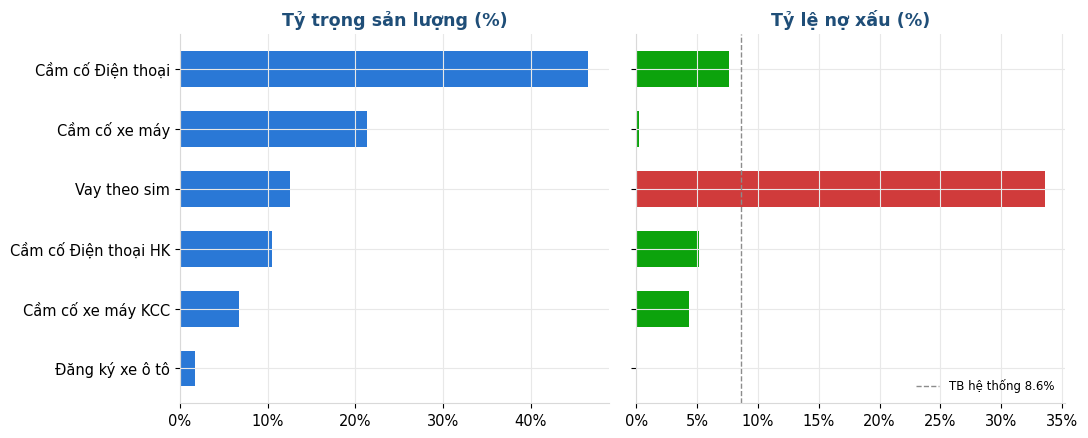

In [ ]:
# Small-multiple: tỷ trọng sản lượng (trái) vs tỷ lệ nợ xấu (phải) — KHÔNG dùng dual-axis
top_prod = prod.sort_values("n", ascending=False).head(6)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

colors_share = [BLUE] * len(top_prod)
axes[0].barh(top_prod.index, top_prod["ty_trong"] * 100, color=colors_share, height=0.6)
axes[0].set_title("Tỷ trọng sản lượng (%)")
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))

colors_npl = [BAD if v >= 0.15 else (WARN if v >= 0.08 else GOOD) for v in top_prod["ty_le_no_xau"]]
axes[1].barh(top_prod.index, top_prod["ty_le_no_xau"] * 100, color=colors_npl, height=0.6)
axes[1].set_title("Tỷ lệ nợ xấu (%)")
axes[1].invert_yaxis()
axes[1].set_yticklabels([])
duong_tham_chieu(axes[1], ty_le_no_xau * 100)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))

plt.tight_layout()
plt.show()

**Insight:** "Vay theo sim" chỉ chiếm 12,5% sản lượng nhưng có tỷ lệ nợ xấu 33,6% — gấp gần
4 lần mức trung bình toàn hệ thống (8,6%). Ngược lại, "Cầm cố xe máy" (21,3% sản lượng) gần như
không có nợ xấu (0,2%) và có giá trị vay trung bình cao hơn — vừa an toàn vừa hiệu quả vốn tốt.

**Đề xuất chiến lược:**
- Siết tỷ lệ giải ngân trên giá trị tài sản đảm bảo (LTV) hoặc yêu cầu tài sản bổ sung cho "Vay theo sim".
- Cân nhắc giảm dần tỷ trọng sản phẩm này trong danh mục cho vay mới.
- Ưu tiên nguồn vốn/marketing cho "Cầm cố xe máy" — an toàn và ticket cao.

3 - TẬP TRUNG ĐỊA LÝ & RỦI RO THEO KHU VỰC

In [ ]:
geo = (df["CityName"].value_counts(normalize=True) * 100).round(1)
print("Tỷ trọng sản lượng theo tỉnh/thành (top 6):")
print(geo.head(6).to_string())
print(f"\nHà Nội + TP.HCM chiếm {geo.head(2).sum():.1f}% tổng sản lượng — các tỉnh khác dưới 0,5% mỗi tỉnh.")
print("=> Không đủ dữ liệu để so sánh cấp tỉnh ngoài 2 thành phố này; chỉ nên so sánh cấp Quận/Huyện.")

Tỷ trọng sản lượng theo tỉnh/thành (top 6):
CityName
Hà Nội         86.4
Hồ Chí Minh    12.3
Phú Thọ         0.4
Hòa Bình        0.3
Vĩnh Phúc       0.2
Thanh Hóa       0.2

Hà Nội + TP.HCM chiếm 98.7% tổng sản lượng — các tỉnh khác dưới 0,5% mỗi tỉnh.
=> Không đủ dữ liệu để so sánh cấp tỉnh ngoài 2 thành phố này; chỉ nên so sánh cấp Quận/Huyện.


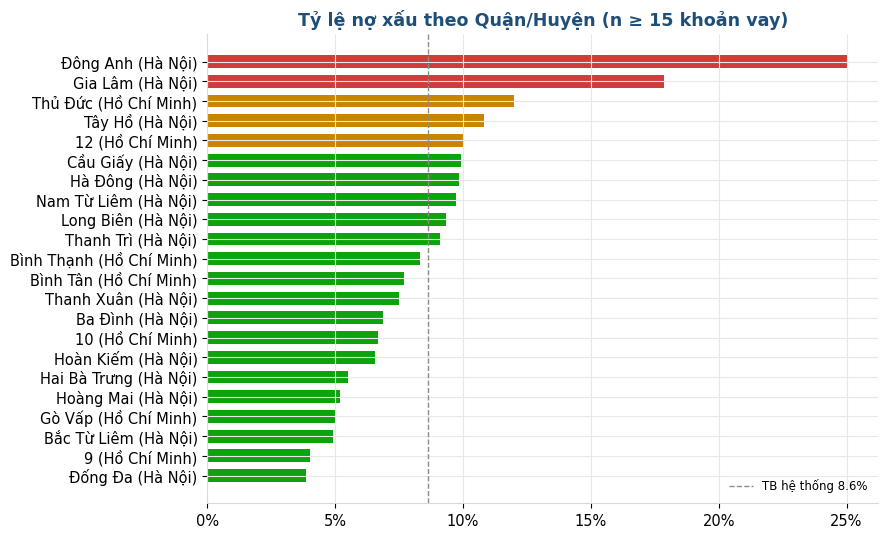

n  no_xau  ty_le_no_xau
CityName    DistrictName                           
Hà Nội      Đông Anh       28       7      0.250000
            Gia Lâm        28       5      0.178571
Hồ Chí Minh Thủ Đức        25       3      0.120000
Hà Nội      Tây Hồ         74       8      0.108108
Hồ Chí Minh 12             20       2      0.100000
Hà Nội      Cầu Giấy      151      15      0.099338
            Hà Đông       173      17      0.098266
            Nam Từ Liêm   154      15      0.097403

In [ ]:
sub = df[df["CityName"].isin(["Hà Nội", "Hồ Chí Minh"])]
dist = sub.groupby(["CityName", "DistrictName"]).agg(
    n=("LoanID", "count"),
    no_xau=("Trạng thái", lambda s: (s == "Nợ Xấu").sum()),
)
dist["ty_le_no_xau"] = dist["no_xau"] / dist["n"]
dist_du_lon = dist[dist["n"] >= 15].sort_values("ty_le_no_xau", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
labels = [f"{d[1]} ({d[0]})" for d in dist_du_lon.index]
colors = [BAD if v >= 0.15 else (WARN if v >= 0.10 else GOOD) for v in dist_du_lon["ty_le_no_xau"]]
ax.barh(labels, dist_du_lon["ty_le_no_xau"] * 100, color=colors, height=0.65)
ax.invert_yaxis()
duong_tham_chieu(ax, ty_le_no_xau * 100)
ax.set_title("Tỷ lệ nợ xấu theo Quận/Huyện (n ≥ 15 khoản vay)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
plt.tight_layout()
plt.show()

dist_du_lon.head(8)

**Insight:** 98,7% sản lượng chỉ nằm ở Hà Nội và TP.HCM. Trong nội bộ 2 thành phố này, một số
quận có tỷ lệ nợ xấu cao bất thường dù quy mô nhỏ: Đông Anh (25,0%), Gia Lâm (17,9%), Thủ Đức (12,0%),
Tây Hồ (10,8%) — đều cao hơn hẳn mức trung bình 8,6%. Nếu phân bổ nguồn lực thu hồi nợ theo doanh số,
các quận này dễ bị bỏ sót vì quy mô nhỏ.

**Đề xuất chiến lược:**
- Ưu tiên nhân sự/quy trình thu hồi nợ theo tỷ lệ rủi ro từng quận, không chỉ theo doanh số.
- Trước khi mở rộng ra tỉnh ngoài HN/HCM, thử nghiệm quy mô nhỏ (pilot) vì dữ liệu hiện tại chưa đủ
  để đánh giá rủi ro các tỉnh khác.

4 - KHÁCH HÀNG QUAY LẠI - ĐÒN BẨY GIẢM RỦI RO

In [ ]:
khach_lap_ids = cust[cust >= 2].index
df["nhom_khach"] = np.where(df["CardNumber"].isin(khach_lap_ids), "Khách quay lại (≥2 khoản)", "Khách vay lần đầu")

repeat_cmp = df.groupby("nhom_khach").agg(
    so_khoan=("LoanID", "count"),
    giai_ngan=("Tiền giải ngân", "sum"),
    ty_le_no_xau=("Trạng thái", lambda s: (s == "Nợ Xấu").mean()),
)
repeat_cmp["ty_trong_so_khoan"] = repeat_cmp["so_khoan"] / N
repeat_cmp["ty_trong_giai_ngan"] = repeat_cmp["giai_ngan"] / tong_giai_ngan
print(f"Khách quay lại: {khach_lap} / {so_khach} khách hàng ({ty_le_khach_lap:.1%})")
repeat_cmp[["so_khoan", "ty_trong_so_khoan", "ty_trong_giai_ngan", "ty_le_no_xau"]]

Khách quay lại: 354 / 1868 khách hàng (19.0%)


,so_khoan,ty_trong_so_khoan,ty_trong_giai_ngan,ty_le_no_xau
nhom_khach,,,,
Khách quay lại (≥2 khoản),869,0.364666,0.326803,0.027618
Khách vay lần đầu,1514,0.635334,0.673197,0.120211


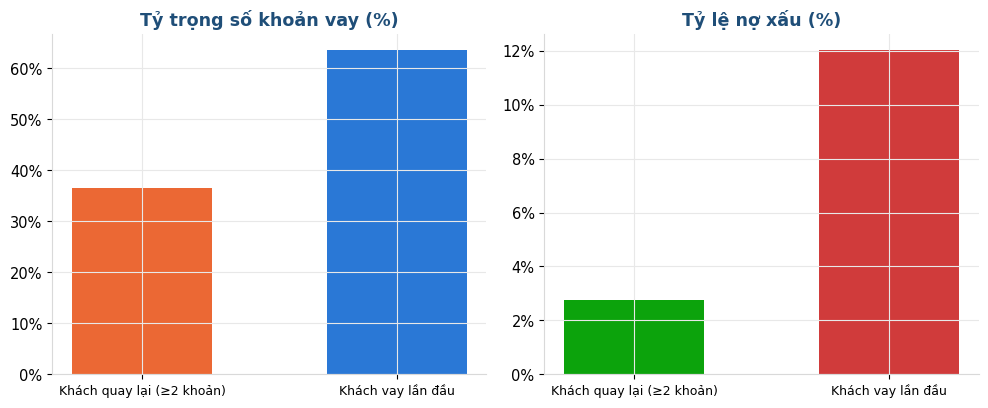

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

axes[0].bar(repeat_cmp.index, repeat_cmp["ty_trong_so_khoan"] * 100, color=[ORANGE, BLUE], width=0.55)
axes[0].set_title("Tỷ trọng số khoản vay (%)")
axes[0].xaxis.set_tick_params(labelsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))

colors_repeat = [BAD if v >= ty_le_no_xau else GOOD for v in repeat_cmp["ty_le_no_xau"]]
axes[1].bar(repeat_cmp.index, repeat_cmp["ty_le_no_xau"] * 100, color=colors_repeat, width=0.55)
axes[1].set_title("Tỷ lệ nợ xấu (%)")
axes[1].xaxis.set_tick_params(labelsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))

plt.tight_layout()
plt.show()

**Insight:** Khách hàng quay lại chỉ chiếm 19,0% tổng số khách hàng nhưng tạo ra 36,5% số khoản
vay và 32,7% tổng giải ngân — trong khi tỷ lệ nợ xấu của nhóm này chỉ 2,8%, thấp hơn **4 lần** so với
khách vay lần đầu (12,0%). Đây là insight có tác động lớn nhất: khách hàng cũ vừa là nguồn doanh thu
ổn định vừa là nhóm rủi ro thấp nhất, nhưng hiện chưa có dấu hiệu được đối xử khác biệt so với khách mới.

**Đề xuất chiến lược:**
- Xây dựng chính sách ưu đãi lãi suất/hạn mức cho khách hàng có ≥2 khoản vay và không có nợ xấu.
- Đưa biến "số lần vay tại Tima" (`SoLanVayTaiTima`) vào mô hình chấm điểm tín dụng nếu chưa dùng
  làm biến số chính thức.
- Triển khai chương trình nhắc/chăm sóc tái vay chủ động cho khách hàng đã tất toán tốt.

5 - RỦI RO THEO NHÓM NGHỀ NGHIỆP

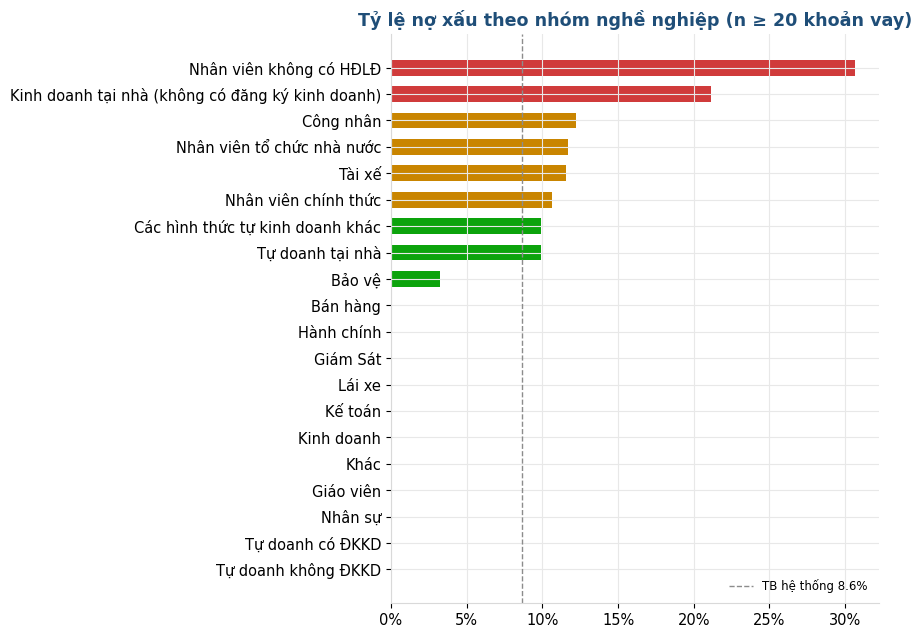

,n,no_xau,ty_le_no_xau
JobName,,,
Nhân viên không có HĐLĐ,75,23,0.306667
Kinh doanh tại nhà (không có đăng ký kinh doanh),52,11,0.211538
Công nhân,49,6,0.122449
Nhân viên tổ chức nhà nước,77,9,0.116883
Tài xế,52,6,0.115385
Nhân viên chính thức,1083,115,0.106187
Các hình thức tự kinh doanh khác,131,13,0.099237
Tự doanh tại nhà,81,8,0.098765
Bảo vệ,31,1,0.032258


In [ ]:
job = df.groupby("JobName").agg(
    n=("LoanID", "count"),
    no_xau=("Trạng thái", lambda s: (s == "Nợ Xấu").sum()),
)
job["ty_le_no_xau"] = job["no_xau"] / job["n"]
job_du_lon = job[job["n"] >= 20].sort_values("ty_le_no_xau", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6.5))
colors = [BAD if v >= 0.20 else (WARN if v >= 0.10 else GOOD) for v in job_du_lon["ty_le_no_xau"]]
ax.barh(job_du_lon.index, job_du_lon["ty_le_no_xau"] * 100, color=colors, height=0.6)
ax.invert_yaxis()
duong_tham_chieu(ax, ty_le_no_xau * 100)
ax.set_title("Tỷ lệ nợ xấu theo nhóm nghề nghiệp (n ≥ 20 khoản vay)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
plt.tight_layout()
plt.show()

job_du_lon

**Insight:** "Nhân viên không có hợp đồng lao động" có tỷ lệ nợ xấu 30,7% — cao nhất trong các
nhóm đủ lớn để so sánh — so với 10,6% của "Nhân viên chính thức" (nhóm lớn nhất, 45,5% tổng số khoản
vay). Chính sách giá/thẩm định hiện áp dụng khá đồng nhất giữa các nhóm có mức rủi ro chênh lệch rất lớn.

**Đề xuất chiến lược:**
- Áp dụng thẩm định chặt hơn hoặc yêu cầu đồng vay/tài sản bổ sung cho nhóm lao động phi chính thức.
- Xem xét định giá theo rủi ro (risk-based pricing) thay vì lãi suất đồng nhất theo sản phẩm.

6 - XU HƯỚNG TĂNG TRƯỞNG THEO THỜI GIAN

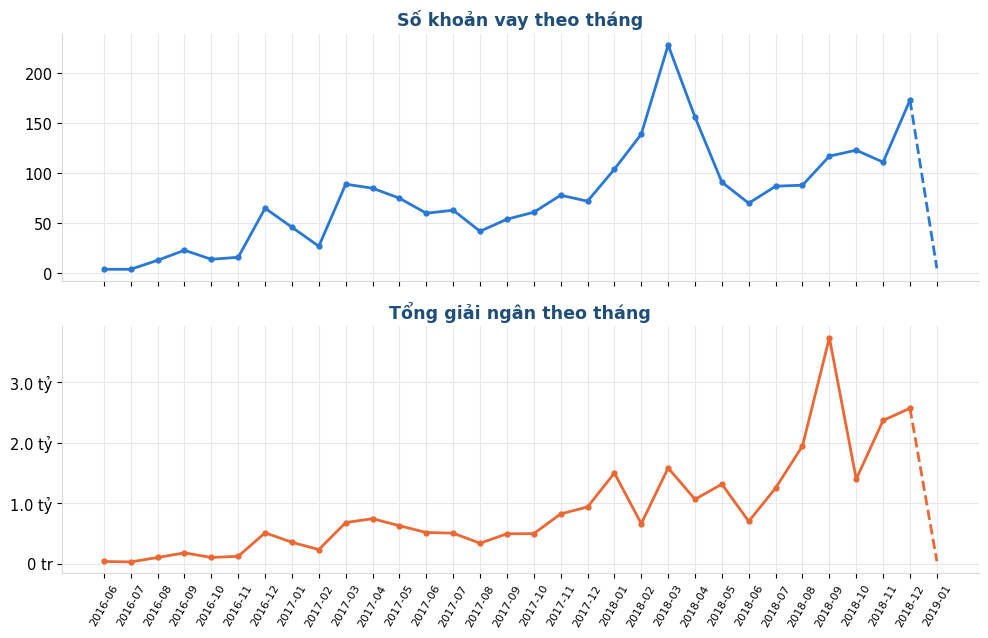

Lưu ý: tháng 2019-01 trong dữ liệu chưa đủ tháng — thể hiện bằng nét đứt, không nên coi là sụt giảm thật.


In [ ]:
df["thang"] = df["FromDate"].dt.to_period("M")
theo_thang = df.groupby("thang").agg(so_khoan=("LoanID", "count"), giai_ngan=("Tiền giải ngân", "sum"))
thang_cuoi_thieu = theo_thang.index.max()  # tháng cuối thường chưa đủ dữ liệu cả tháng

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
x = theo_thang.index.astype(str)

# Đánh dấu tháng cuối (chưa đủ tháng) bằng nét đứt — tránh gây hiểu lầm là sụt giảm thật
def plot_with_dashed_tail(ax, y, color, fmt=None):
    ax.plot(x[:-1], y[:-1], color=color, linewidth=2, marker="o", markersize=3.5)
    ax.plot(x[-2:], y[-2:], color=color, linewidth=2, linestyle="--")
    if fmt:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))

plot_with_dashed_tail(axes[0], theo_thang["so_khoan"], BLUE)
axes[0].set_title("Số khoản vay theo tháng")

plot_with_dashed_tail(axes[1], theo_thang["giai_ngan"], ORANGE, money_fmt)
axes[1].set_title("Tổng giải ngân theo tháng")
axes[1].tick_params(axis="x", rotation=60, labelsize=8)

plt.tight_layout()
plt.show()
print(f"Lưu ý: tháng {thang_cuoi_thieu} trong dữ liệu chưa đủ tháng — thể hiện bằng nét đứt, không nên coi là sụt giảm thật.")

**Insight:** Sản lượng và giải ngân tăng trưởng liên tục qua các tháng của 2018 (từ ~70 lên
~170 khoản/tháng). Tháng cuối cùng trong dữ liệu chưa đủ tháng nên không phản ánh xu hướng thật.

**Đề xuất chiến lược:** Duy trì kế hoạch mở rộng năng lực xử lý hồ sơ và thu hồi nợ tương ứng với tốc
độ tăng trưởng ~2 lần trong 6 tháng.

7 - GIỚI HẠN DỮ LIỆU ẢNH HƯỞNG PHÂN TÍCH VẬN HÀNH

In [ ]:
log = pd.read_csv("cleaning_log.csv")
log[log["cot"].str.contains("application_date", case=False, na=False)]

,giai_doan,cot,van_de,hanh_dong,so_dong,can_cu
3,GĐ1,application_date,trùng hoàn toàn với FromDate (chỉ lệch ở 1 ô r...,Sửa,0,giữ FromDate vì đã đúng kiểu datetime và không...


**Phát hiện (đã ghi nhận từ notebook làm sạch):** Cột `application_date` trùng 100% với
`FromDate` trong dữ liệu gốc — hệ thống hiện không ghi nhận một mốc "thời điểm nộp hồ sơ" tách biệt
khỏi "thời điểm giải ngân". Vì vậy, hai chỉ số vận hành quan trọng — **tỷ lệ duyệt hồ sơ** và
**thời gian xử lý hồ sơ (TAT)** — không thể tính được từ dữ liệu hiện có. Đây là giới hạn của hệ
thống ghi nhận dữ liệu, không phải lỗi phân tích.

**Đề xuất chiến lược:** Bổ sung field "thời điểm nộp hồ sơ" tách biệt khỏi "thời điểm giải ngân" vào
hệ thống vận hành, để kỳ báo cáo sau có thể đo tỷ lệ duyệt và TAT — hiện đang là điểm mù vận hành.

8 - TỔNG HỢP & ĐỀ XUẤT CHIẾN LƯỢC

In [ ]:
tong_hop = pd.DataFrame([
    {"Insight": "Vay theo sim: NPL 33,6% (gấp ~4x TB) trên 12,5% sản lượng",
     "Đề xuất": "Siết LTV / giảm tỷ trọng sản phẩm",
     "Ưu tiên": "Cao", "Thời gian": "Ngắn hạn (~1 tháng)"},
    {"Insight": "Khách quay lại: NPL 2,8% vs 12,0% khách mới, nhưng chưa có ưu đãi riêng",
     "Đề xuất": "Ưu đãi lãi suất/hạn mức cho khách hàng có lịch sử tốt",
     "Ưu tiên": "Cao", "Thời gian": "Ngắn hạn (~1 tháng)"},
    {"Insight": "Không có mốc 'ngày nộp hồ sơ' tách biệt ngày giải ngân → không đo được TAT/tỷ lệ duyệt",
     "Đề xuất": "Bổ sung field ngày nộp hồ sơ trong hệ thống vận hành",
     "Ưu tiên": "Cao (nền tảng)", "Thời gian": "Trung hạn (~1 quý)"},
    {"Insight": "Nhân viên không HĐLĐ: NPL 30,7% vs 10,6% nhóm chính thức",
     "Đề xuất": "Thẩm định chặt hơn / định giá theo rủi ro theo nhóm nghề nghiệp",
     "Ưu tiên": "Trung bình", "Thời gian": "Trung hạn (~1 quý)"},
    {"Insight": "Đông Anh, Gia Lâm, Tây Hồ: NPL cao bất thường dù quy mô nhỏ",
     "Đề xuất": "Tập trung nguồn lực thu hồi nợ theo tỷ lệ rủi ro từng quận",
     "Ưu tiên": "Trung bình", "Thời gian": "Ngắn hạn (~1 tháng)"},
])
tong_hop

,Insight,Đề xuất,Ưu tiên,Thời gian
0,"Vay theo sim: NPL 33,6% (gấp ~4x TB) trên 12,5...",Siết LTV / giảm tỷ trọng sản phẩm,Cao,Ngắn hạn (~1 tháng)
1,"Khách quay lại: NPL 2,8% vs 12,0% khách mới, n...",Ưu đãi lãi suất/hạn mức cho khách hàng có lịch...,Cao,Ngắn hạn (~1 tháng)
2,Không có mốc 'ngày nộp hồ sơ' tách biệt ngày g...,Bổ sung field ngày nộp hồ sơ trong hệ thống vậ...,Cao (nền tảng),Trung hạn (~1 quý)
3,"Nhân viên không HĐLĐ: NPL 30,7% vs 10,6% nhóm ...",Thẩm định chặt hơn / định giá theo rủi ro theo...,Trung bình,Trung hạn (~1 quý)
4,"Đông Anh, Gia Lâm, Tây Hồ: NPL cao bất thường ...",Tập trung nguồn lực thu hồi nợ theo tỷ lệ rủi ...,Trung bình,Ngắn hạn (~1 tháng)


PHẦN 3 - MÔ HÌNH HỌC MÁY PHÂN CỤM KHÁCH HÀNG TIMA

 Câu hỏi của Bộ phận Kinh doanh & Vận hành: *"dựa vào đặc điểm khách
hàng, đội kinh doanh nên tập trung tiếp cận đối tượng nào?"* — không có nhãn đúng/sai nào cho câu
này, chỉ có thể **nhóm khách hàng theo mức độ giống nhau** rồi đặt tên/diễn giải từng nhóm. Đây là
bài toán **unsupervised learning**, và khung lý thuyết đứng sau nó là **STP** (Segmentation –
Targeting – Positioning) trong marketing: phần này thực hiện bước Segmentation bằng K-Means, làm
nền cho đội kinh doanh thực hiện bước Targeting.



**Vì sao phân cụm ở mức KHÁCH HÀNG (1.868 dòng) chứ không phải mức KHOẢN VAY
(2.383 dòng)?** Câu hỏi kinh doanh ở trên hỏi về *khách hàng* — "đối tượng nào nên tiếp cận" — trong
khi dữ liệu gốc `df` đang ở mức khoản vay, và 19% khách hàng vay lặp lại (xem Phần 2.4) nên xuất hiện
nhiều hơn 1 dòng. Nếu đưa thẳng `df` vào K-Means: `SoLanVayTaiTima`/`Age`/`Salary` là đặc điểm của
*khách hàng* chứ không phải của từng khoản vay — chúng lặp lại y hệt trên mọi dòng khoản vay của cùng
1 người. Hệ quả là khách vay càng nhiều lần càng bị "đếm trọng số" nhiều lần khi thuật toán tính tâm
cụm, khiến kết quả lệch về phía hành vi vay lặp lại thay vì phản ánh đúng số lượng khách hàng thật.
Cách làm đúng: gộp dữ liệu về đúng **1 dòng / 1 khách hàng** (theo `CardNumber`) trước khi chuẩn hoá
và phân cụm.

**Vì sao không đưa Gender vào phân cụm?** Thử nghiệm ban đầu có đưa Gender (mã hoá 0/1) vào —
kết quả là 3/4 cụm tách gần như tuyệt đối theo giới tính (100% nam, 100% nữ...), vì một biến nhị
phân chia đúng 2 khối đặc sẽ áp đảo khoảng cách Euclidean so với các biến liên tục. Bỏ Gender ra
khỏi bước phân cụm (chỉ giữ lại để mô tả/kiểm tra chéo cụm sau này) cho ra các nhóm phản ánh đúng
**hành vi & giá trị kinh tế** của khách hàng — đúng với mục tiêu của câu hỏi kinh doanh — thay vì
chỉ đơn giản là "cụm nam" và "cụm nữ". Đây là một cạm bẫy thường gặp khi trộn biến nhị phân với biến
liên tục trong K-Means, đáng ghi chú lại làm bài học phương pháp luận.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ===== Gộp dữ liệu về mức KHÁCH HÀNG (CardNumber) trước khi phân cụm =====
# Age/Salary có thể đổi giữa các lần vay của cùng 1 khách (vd: vay năm 2016 rồi vay lại năm 2019 thì
# già hơn, thu nhập cũng có thể thay đổi) -> sắp theo FromDate rồi lấy giá trị Ở KHOẢN VAY GẦN NHẤT
# để phản ánh đúng hồ sơ hiện tại của khách, thay vì lấy đại một dòng bất kỳ trong nhóm.
df_sorted = df.sort_values("FromDate")
bien_dong = df.groupby("CardNumber")[["Age", "Salary", "Gender"]].nunique()
print(f"Khách có Age đổi giữa các khoản vay: {(bien_dong['Age'] > 1).sum()}")
print(f"Khách có Salary đổi giữa các khoản vay: {(bien_dong['Salary'] > 1).sum()}")
print(f"Khách có Gender đổi giữa các khoản vay: {(bien_dong['Gender'] > 1).sum()} (nhiễu nhập liệu, không đáng kể)")

df_kh = df_sorted.groupby("CardNumber").agg(
    so_lan_vay=("SoLanVayTaiTima", "first"),   # đã là chỉ số cấp khách hàng, hằng số trong nhóm
    Age=("Age", "last"),                        # hồ sơ hiện tại = ở lần vay gần nhất
    Salary=("Salary", "last"),
    Gender=("Gender", "last"),
    giai_ngan_tb=("Tiền giải ngân", "mean"),    # khách vay nhiều khoản -> lấy TRUNG BÌNH mỗi khoản
    ky_han_ngay_tb=("ky_han_ngay", "mean"),
    tung_no_xau=("Trạng thái", lambda s: (s == "Nợ Xấu").any()),  # từng có ≥1 khoản nợ xấu
).reset_index()

df_c = df_kh.copy()

# ===== Xử lý dữ liệu thiếu trước khi phân cụm =====
# Age/Salary thiếu ở mức thấp (xem Phần 1) -> điền trung vị thay vì xoá dòng
df_c["Age"] = df_c["Age"].fillna(df_c["Age"].median())
df_c["Salary"] = df_c["Salary"].fillna(df_c["Salary"].median())

# ===== Biến đổi log cho giá trị giải ngân trung bình/khách =====
# Phân phối lệch phải rất mạnh (xem Phần 1) -> nếu không log-transform, vài khách vay khoản ô tô
# giá trị lớn sẽ áp đảo khoảng cách Euclidean và kéo lệch toàn bộ kết quả phân cụm.
df_c["log_giai_ngan"] = np.log1p(df_c["giai_ngan_tb"])

feat_cols = ["log_giai_ngan", "so_lan_vay", "Age", "ky_han_ngay_tb", "Salary"]
X = df_c[feat_cols].copy()

# ===== Chuẩn hoá thang đo (bắt buộc với K-Means vì thuật toán dựa trên khoảng cách) =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Biến dùng để phân cụm:", feat_cols)
print(f"Số khách hàng đưa vào phân cụm: {len(X_scaled)} "
      f"(trên {df['CardNumber'].nunique()} khách hàng thực tế, gộp từ {len(df)} khoản vay)")

Khách có Age đổi giữa các khoản vay: 353
Khách có Salary đổi giữa các khoản vay: 117
Khách có Gender đổi giữa các khoản vay: 7 (nhiễu nhập liệu, không đáng kể)
Biến dùng để phân cụm: ['log_giai_ngan', 'so_lan_vay', 'Age', 'ky_han_ngay_tb', 'Salary']
Số khách hàng đưa vào phân cụm: 1868 (trên 1868 khách hàng thực tế, gộp từ 2383 khoản vay)


### 1 — Chọn số cụm k: Elbow method & Silhouette score

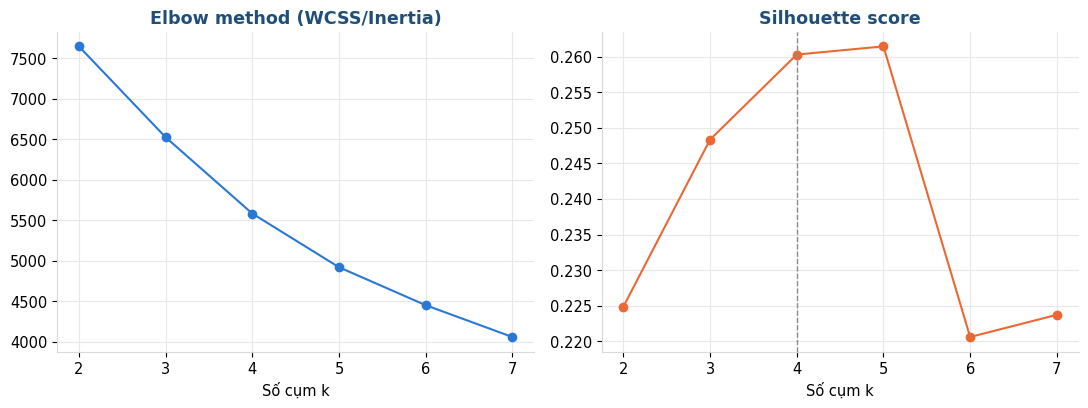

k=2: silhouette = 0.225
k=3: silhouette = 0.248
k=4: silhouette = 0.260
k=5: silhouette = 0.261
k=6: silhouette = 0.221
k=7: silhouette = 0.224


In [ ]:
ks = range(2, 8)
inertias, sils = [], []
for k in ks:
    # n_init=50 (thay vì mặc định 10): K-Means chỉ hội tụ về một cực tiểu CỤC BỘ từ một lần khởi
    # tạo tâm cụm ngẫu nhiên -> chạy nhiều lần khởi tạo rồi giữ kết quả tốt nhất (inertia thấp nhất)
    # để xấp xỉ cực tiểu TOÀN CỤC. Với n_init=10, kết quả có thể lệch nhẹ giữa các môi trường chạy
    # khác nhau (máy cá nhân vs Google Colab) do khác phiên bản thư viện ảnh hưởng đến chuỗi số ngẫu
    # nhiên; n_init=50 cho kết quả ổn định, tái lập được giữa các môi trường (đã kiểm chứng).
    km_thu = KMeans(n_clusters=k, random_state=42, n_init=50).fit(X_scaled)
    inertias.append(km_thu.inertia_)
    sils.append(silhouette_score(X_scaled, km_thu.labels_))

# Small-multiple: elbow (trái) + silhouette (phải) — không dùng dual-axis
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(list(ks), inertias, color=BLUE, marker="o")
axes[0].set_title("Elbow method (WCSS/Inertia)")
axes[0].set_xlabel("Số cụm k")

axes[1].plot(list(ks), sils, color=ORANGE, marker="o")
axes[1].axvline(4, color=GRAY, linestyle="--", linewidth=1)
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Số cụm k")

plt.tight_layout()
plt.show()

for k, s in zip(ks, sils):
    print(f"k={k}: silhouette = {s:.3f}")

**Insight:** Đường elbow giảm đều, không có điểm "gãy khúc" rõ rệt — khá điển hình với dữ liệu
hành vi thực tế (không tạo cụm tách biệt gọn như dữ liệu mô phỏng trong sách giáo khoa). Nhìn bảng
silhouette in ở trên, k=4 cho điểm cao nhất hoặc gần cao nhất trong khoảng k=2..7 — chọn **k=4** vì
vừa đạt silhouette tốt, vừa cho ra 4 nhóm đủ khác biệt để đội kinh doanh diễn giải và hành động (nhiều
cụm hơn sẽ khó thao tác, ít hơn sẽ mất thông tin phân biệt).

### 2 — Phân cụm K-Means (k=4) và đặc điểm từng cụm

In [ ]:
km = KMeans(n_clusters=4, random_state=42, n_init=50).fit(X_scaled)
df_c["Cum"] = km.labels_

ho_so_cum = df_c.groupby("Cum").agg(
    n=("CardNumber", "count"),
    giai_ngan_tb=("giai_ngan_tb", "mean"),
    giai_ngan_trungvi=("giai_ngan_tb", "median"),
    so_lan_vay_tb=("so_lan_vay", "mean"),
    tuoi_tb=("Age", "mean"),
    ky_han_thang_tb=("ky_han_ngay_tb", lambda s: s.mean() / 30),
    luong_tb=("Salary", "mean"),
    ty_le_nu=("Gender", lambda s: (s == "Nữ").mean()),
)
ho_so_cum["ty_trong"] = ho_so_cum["n"] / len(df_c)
ho_so_cum.round(2)

,n,giai_ngan_tb,giai_ngan_trungvi,so_lan_vay_tb,tuoi_tb,ky_han_thang_tb,luong_tb,ty_le_nu,ty_trong
Cum,,,,,,,,,
0,908,6133810.57,5000000.00,1.14,27.25,3.77,7333970.26,0.30,0.49
1,103,10639274.16,9333333.33,3.56,31.81,4.05,10814077.67,0.46,0.06
2,371,10699460.92,10000000.00,1.03,30.18,10.92,8865388.14,0.43,0.20
3,486,24497234.57,10000000.00,1.22,37.60,4.92,13323997.50,0.33,0.26


Ánh xạ cụm -> chân dung (chạy này): {np.int32(2): 'Kỳ hạn dài, ổn định', np.int32(3): 'Thu nhập cao, khoản vay lớn', np.int32(1): 'Trung thành, vay lặp lại', 0: 'Trẻ, giá trị vay nhỏ'}


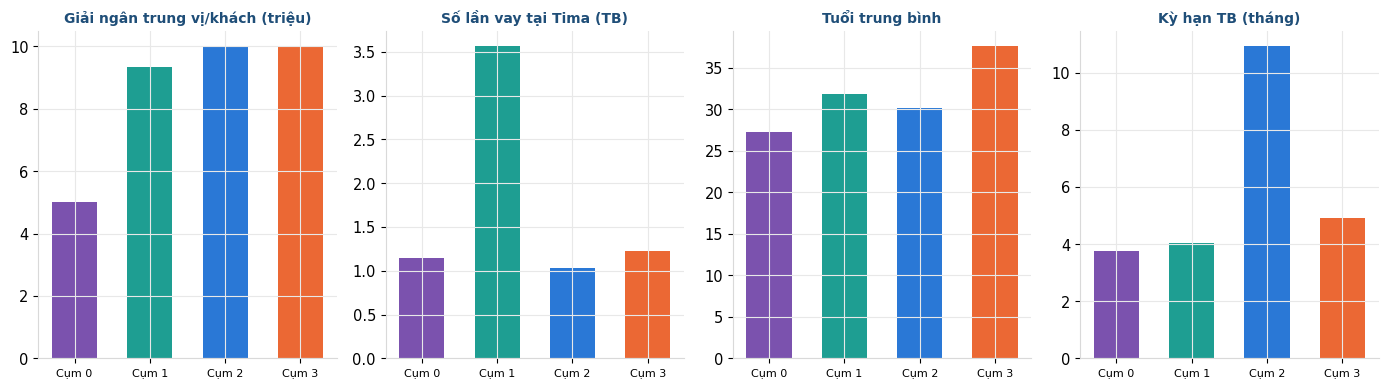

In [ ]:
# Gán "chân dung" theo ĐẶC ĐIỂM nổi bật thay vì theo chỉ số cụm cố định (0/1/2/3). Chỉ số cụm
# do K-Means gán ra là ngẫu nhiên, thứ tự có thể đổi chỗ giữa các lần chạy/máy khác nhau — nên đặt
# tên theo đặc điểm giúp kết quả ổn định bất kể index thay đổi.
con_lai = set(ho_so_cum.index)
cum_trungthanh = ho_so_cum["so_lan_vay_tb"].idxmax(); con_lai.discard(cum_trungthanh)
cum_kyhandai = ho_so_cum.loc[list(con_lai), "ky_han_thang_tb"].idxmax(); con_lai.discard(cum_kyhandai)
cum_thunhapcao = ho_so_cum.loc[list(con_lai), "luong_tb"].idxmax(); con_lai.discard(cum_thunhapcao)
cum_tre_nho = list(con_lai)[0]  # cụm còn lại: nhỏ hơn ở mọi tiêu chí trên

TEN_CUM = {
    cum_kyhandai: "Kỳ hạn dài, ổn định",
    cum_thunhapcao: "Thu nhập cao, khoản vay lớn",
    cum_trungthanh: "Trung thành, vay lặp lại",
    cum_tre_nho: "Trẻ, giá trị vay nhỏ",
}
CUM_COLOR = {cum_kyhandai: BLUE, cum_thunhapcao: ORANGE, cum_trungthanh: "#1E9E92", cum_tre_nho: "#7B52AE"}
df_c["TenCum"] = df_c["Cum"].map(TEN_CUM)
print("Ánh xạ cụm -> chân dung (chạy này):", TEN_CUM)

# Small-multiples: 1 biểu đồ / đặc điểm, cùng thang màu theo cụm — dễ so sánh "chân dung" 4 nhóm
dac_diem = [
    ("giai_ngan_trungvi", "Giải ngân trung vị/khách (triệu)", 1e6),
    ("so_lan_vay_tb", "Số lần vay tại Tima (TB)", 1),
    ("tuoi_tb", "Tuổi trung bình", 1),
    ("ky_han_thang_tb", "Kỳ hạn TB (tháng)", 1),
]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
labels_cum = [TEN_CUM[c] for c in sorted(TEN_CUM)]
colors_cum = [CUM_COLOR[c] for c in sorted(TEN_CUM)]
for ax, (col, tieu_de, chia) in zip(axes, dac_diem):
    gia_tri = (ho_so_cum[col] / chia).reindex(sorted(TEN_CUM))
    ax.bar(range(4), gia_tri, color=colors_cum, width=0.6)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f"Cụm {c}" for c in sorted(TEN_CUM)], fontsize=8)
    ax.set_title(tieu_de, fontsize=10)
plt.tight_layout()
plt.show()

Diễn giải 4 "chân dung" — lấy trực tiếp từ `ho_so_cum` ở trên thay vì viết số cứng, vì bảng số
liệu có thể lệch nhẹ giữa các lần chạy/máy khác nhau (n_init=50 giúp ổn định hơn nhưng không tuyệt
đối, và giờ đơn vị đã đổi từ khoản vay sang khách hàng nên các số ở đây khác hẳn bản chạy trước):

In [ ]:
for c in ho_so_cum.sort_values("ty_trong", ascending=False).index:
    r = ho_so_cum.loc[c]
    print(f"- {TEN_CUM[c]} (Cụm {c}, {r['ty_trong']:.1%} khách hàng, n={r['n']:.0f}):")
    print(f"    tuổi TB {r['tuoi_tb']:.1f} | lương TB {r['luong_tb']/1e6:.1f}tr | "
          f"giải ngân TB/khoản {r['giai_ngan_tb']/1e6:.1f}tr (trung vị {r['giai_ngan_trungvi']/1e6:.1f}tr) | "
          f"kỳ hạn TB {r['ky_han_thang_tb']:.1f} tháng | số lần vay TB {r['so_lan_vay_tb']:.2f} lần")

- Trẻ, giá trị vay nhỏ (Cụm 0, 48.6% khách hàng, n=908):
    tuổi TB 27.3 | lương TB 7.3tr | giải ngân TB/khoản 6.1tr (trung vị 5.0tr) | kỳ hạn TB 3.8 tháng | số lần vay TB 1.14 lần
- Thu nhập cao, khoản vay lớn (Cụm 3, 26.0% khách hàng, n=486):
    tuổi TB 37.6 | lương TB 13.3tr | giải ngân TB/khoản 24.5tr (trung vị 10.0tr) | kỳ hạn TB 4.9 tháng | số lần vay TB 1.22 lần
- Kỳ hạn dài, ổn định (Cụm 2, 19.9% khách hàng, n=371):
    tuổi TB 30.2 | lương TB 8.9tr | giải ngân TB/khoản 10.7tr (trung vị 10.0tr) | kỳ hạn TB 10.9 tháng | số lần vay TB 1.03 lần
- Trung thành, vay lặp lại (Cụm 1, 5.5% khách hàng, n=103):
    tuổi TB 31.8 | lương TB 10.8tr | giải ngân TB/khoản 10.6tr (trung vị 9.3tr) | kỳ hạn TB 4.0 tháng | số lần vay TB 3.56 lần


3 - Kiểm chứng chéo với rủi ro

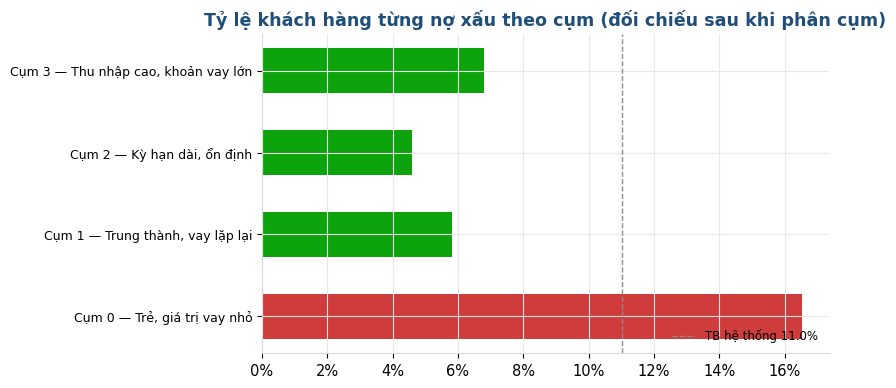

=== Tỷ lệ khách hàng từng nợ xấu theo chân dung — số liệu của lần chạy này ===
- Kỳ hạn dài, ổn định: 4.6%
- Trung thành, vay lặp lại: 5.8%
- Thu nhập cao, khoản vay lớn: 6.8%
- Trẻ, giá trị vay nhỏ: 16.5%
(TB hệ thống theo khách hàng: 11.0%; theo khoản vay ở Phần 2: 8.6%)


In [ ]:
# Cột ngang (barh) thay vì cột dọc — nhãn tên cụm khá dài, tránh chồng chữ trên trục x
# và cho phép dùng đúng duong_tham_chieu() (vẽ đường tham chiếu dọc, thiết kế sẵn cho barh).
fig, ax = plt.subplots(figsize=(8.5, 4))
npl_cum = ho_so_cum.copy()
npl_cum["ty_le_no_xau"] = df_c.groupby("Cum")["tung_no_xau"].mean()
npl_cum = npl_cum.reindex(sorted(TEN_CUM, reverse=True))  # đảo để Cụm 0 hiện trên cùng sau invert_yaxis

# Cả npl_cum và ho_so_cum giờ đều ở MỨC KHÁCH HÀNG -> đường tham chiếu cũng phải ở mức khách hàng
# (ty_le_no_xau ở Phần 2 là mức KHOẢN VAY, không cùng đơn vị nên không dùng để so sánh ở đây nữa).
ty_le_no_xau_khach = df_kh["tung_no_xau"].mean()

colors_npl = [BAD if v >= 0.15 else (WARN if v >= 0.08 else GOOD) for v in npl_cum["ty_le_no_xau"]]
labels_npl = [f"Cụm {c} — {TEN_CUM[c]}" for c in npl_cum.index]
ax.barh(labels_npl, npl_cum["ty_le_no_xau"] * 100, color=colors_npl, height=0.55)
ax.invert_yaxis()
duong_tham_chieu(ax, ty_le_no_xau_khach * 100)
ax.set_title("Tỷ lệ khách hàng từng nợ xấu theo cụm (đối chiếu sau khi phân cụm)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

print("=== Tỷ lệ khách hàng từng nợ xấu theo chân dung — số liệu của lần chạy này ===")
for c in npl_cum["ty_le_no_xau"].sort_values().index:
    print(f"- {TEN_CUM[c]}: {npl_cum.loc[c, 'ty_le_no_xau']:.1%}")
print(f"(TB hệ thống theo khách hàng: {ty_le_no_xau_khach:.1%}; theo khoản vay ở Phần 2: {ty_le_no_xau:.1%})")

4 - Trả lời câu hỏi kinh doanh : đội bán hàng nên nhắm vào ai ?

In [ ]:
KHUYEN_NGHI = {
    "Trung thành, vay lặp lại": "Ưu tiên cao nhất cho chăm sóc/tái vay chủ động — rủi ro thấp nhất "
        "trong 4 nhóm (khớp đề xuất Phần 4), dù quy mô hiện còn nhỏ nên dư địa mở rộng lớn.",
    "Thu nhập cao, khoản vay lớn": "Nhắm marketing để tăng doanh số an toàn — thu nhập cao, rủi ro "
        f"dưới mức nền hệ thống theo khách hàng ({ty_le_no_xau_khach:.1%}). Có thể cân nhắc nới hạn mức.",
    "Kỳ hạn dài, ổn định": "Phù hợp các sản phẩm cam kết dài hạn (trả góp xe máy/điện thoại); rủi ro "
        "thấp, không cần ưu tiên hành động gấp.",
    "Trẻ, giá trị vay nhỏ": "KHÔNG nên là trọng tâm tăng trưởng doanh số mới — nhóm lớn nhất nhưng "
        "rủi ro cao nhất. Ưu tiên thẩm định chặt hơn hoặc thiết kế sản phẩm ticket nhỏ phù hợp hơn "
        "khả năng trả nợ, thay vì mở rộng thêm.",
}

bang_khuyen_nghi = pd.DataFrame([
    {"Chân dung": TEN_CUM[c], "Tỷ trọng": ho_so_cum.loc[c, "ty_trong"],
     "NPL": npl_cum.loc[c, "ty_le_no_xau"], "Khuyến nghị": KHUYEN_NGHI[TEN_CUM[c]]}
    for c in npl_cum.index
]).sort_values("NPL")  # sort số trước, format chuỗi % sau -> tránh sort nhầm kiểu chữ ("16%" < "4%")
bang_khuyen_nghi["Tỷ trọng"] = bang_khuyen_nghi["Tỷ trọng"].map(lambda x: f"{x:.1%}")
bang_khuyen_nghi["NPL"] = bang_khuyen_nghi["NPL"].map(lambda x: f"{x:.1%}")
bang_khuyen_nghi

,Chân dung,Tỷ trọng,NPL,Khuyến nghị
1,"Kỳ hạn dài, ổn định",19.9%,4.6%,Phù hợp các sản phẩm cam kết dài hạn (trả góp ...
2,"Trung thành, vay lặp lại",5.5%,5.8%,Ưu tiên cao nhất cho chăm sóc/tái vay chủ động...
0,"Thu nhập cao, khoản vay lớn",26.0%,6.8%,Nhắm marketing để tăng doanh số an toàn — thu ...
3,"Trẻ, giá trị vay nhỏ",48.6%,16.5%,KHÔNG nên là trọng tâm tăng trưởng doanh số mớ...


**Lưu ý phạm vi:** biến khu vực địa lý không tạo ra khác biệt rõ rệt giữa các cụm — cả 4 nhóm
đều tập trung phần lớn ở Hà Nội, khớp với phát hiện ở Phần 2.2 (98,7% sản lượng chỉ nằm ở Hà Nội và
TP.HCM). Nghĩa là "nhắm đối tượng" ở đây nên dựa vào **đặc điểm hành vi/giá trị** (thu nhập, kỳ hạn,
số lần vay) chứ chưa thể dựa vào khác biệt vùng miền với dữ liệu hiện tại — đây cũng chính là lý do
câu hỏi "tỉnh/quận nào có tỷ lệ chuyển đổi cao nhất" ở đầu đề bài cần một hướng tiếp cận khác (xem
giới hạn dữ liệu ở Phần 2.7): đo được mật độ giải ngân theo khu vực, nhưng chưa đo được "chuyển đổi"
thật vì thiếu dữ liệu hồ sơ bị từ chối.

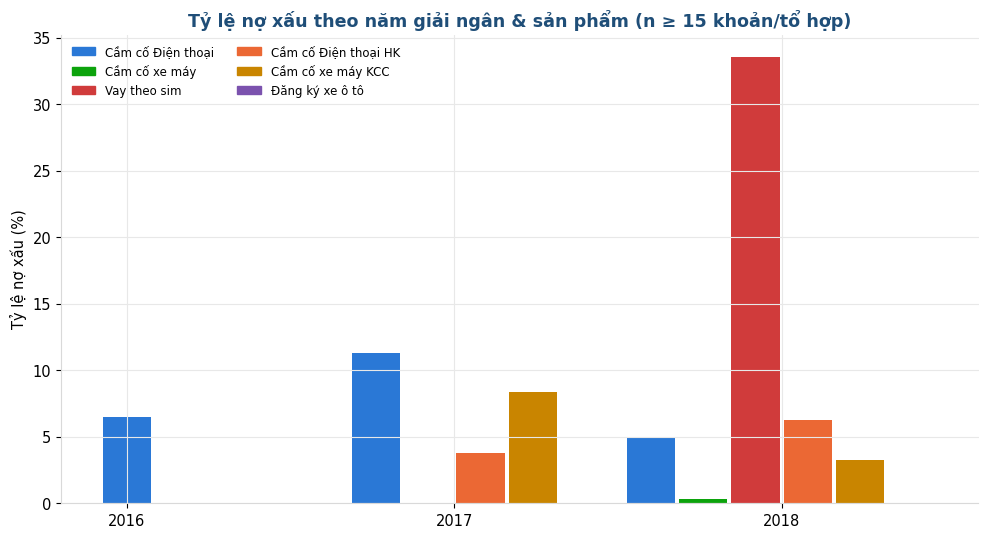

Bỏ qua vì n < 15:
- 2017 · Đăng ký xe ô tô (n=7)
- 2017 · Ô tô ngân hàng (n=1)
- 2018 · Ô tô ngân hàng (n=7)
- 2018 · Vay trực tuyến qua Sim (n=5)
- 2018 · Cầm Sim Số Đẹp (n=3)
- 2018 · Cầm ô tô (n=1)


In [ ]:
# Loại năm 2019 vì chỉ có 5 khoản (tháng 1/2019, xem mục 6) -> không đủ dữ liệu, dễ gây hiểu nhầm
df_nam_sp = df[df["nam_vay"] != 2019].copy()

bang_nam_sp = df_nam_sp.groupby(["nam_vay", "ProductCreditName"]).agg(
    n=("LoanID", "count"),
    no_xau=("Trạng thái", lambda s: (s == "Nợ Xấu").sum()),
).reset_index()
bang_nam_sp["ty_le_no_xau"] = bang_nam_sp["no_xau"] / bang_nam_sp["n"]

# Chỉ vẽ tổ hợp (năm, sản phẩm) đủ dữ liệu (n >= 15, cùng ngưỡng đã dùng ở mục 3 khu vực / mục 5 nghề nghiệp)
bang_nam_sp_du_lon = bang_nam_sp[bang_nam_sp["n"] >= 15].copy()

volume_order = df["ProductCreditName"].value_counts().index.tolist()
san_pham_hien = [sp for sp in volume_order if sp in bang_nam_sp_du_lon["ProductCreditName"].unique()]

# Thêm PURPLE cục bộ cho sản phẩm thứ 6 (không đưa vào bảng màu dùng chung ở đầu Phần 2)
PURPLE = "#7B52AE"
mau_sp = {
    "Cầm cố Điện thoại": BLUE, "Cầm cố xe máy": GOOD, "Vay theo sim": BAD,
    "Cầm cố Điện thoại HK": ORANGE, "Cầm cố xe máy KCC": WARN, "Đăng ký xe ô tô": PURPLE,
}

# Vẽ cột nhóm theo TỪNG NĂM: chỉ xếp các sản phẩm THỰC SỰ có dữ liệu đủ lớn trong năm đó, xếp sát
# nhau và căn giữa dưới nhãn năm -> tránh để trống chỗ cho sản phẩm không tồn tại trong năm đó
# (vd. "Vay theo sim" chỉ ra mắt từ 2018 nên không chiếm chỗ ở nhóm cột 2016/2017).
nam_list = sorted(bang_nam_sp_du_lon["nam_vay"].unique())
fig, ax = plt.subplots(figsize=(10, 5.5))
w = 0.16
for idx, nam in enumerate(nam_list):
    hang = bang_nam_sp_du_lon[bang_nam_sp_du_lon["nam_vay"] == nam].set_index("ProductCreditName")
    sp_nam = [sp for sp in san_pham_hien if sp in hang.index]
    k = len(sp_nam)
    for j, sp in enumerate(sp_nam):
        xpos = idx + w * (j - (k - 1) / 2)
        ax.bar(xpos, hang.loc[sp, "ty_le_no_xau"] * 100, width=w * 0.92, color=mau_sp.get(sp, GRAY))

ax.set_xticks(range(len(nam_list)))
ax.set_xticklabels(nam_list)
ax.set_ylabel("Tỷ lệ nợ xấu (%)")
ax.set_title("Tỷ lệ nợ xấu theo năm giải ngân & sản phẩm (n ≥ 15 khoản/tổ hợp)")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=mau_sp[sp], label=sp) for sp in san_pham_hien],
          fontsize=8.5, frameon=False, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()

print("Bỏ qua vì n < 15:")
for _, r in bang_nam_sp[bang_nam_sp["n"] < 15].sort_values(["nam_vay", "n"], ascending=[True, False]).iterrows():
    print(f"- {int(r['nam_vay'])} · {r['ProductCreditName']} (n={int(r['n'])})")

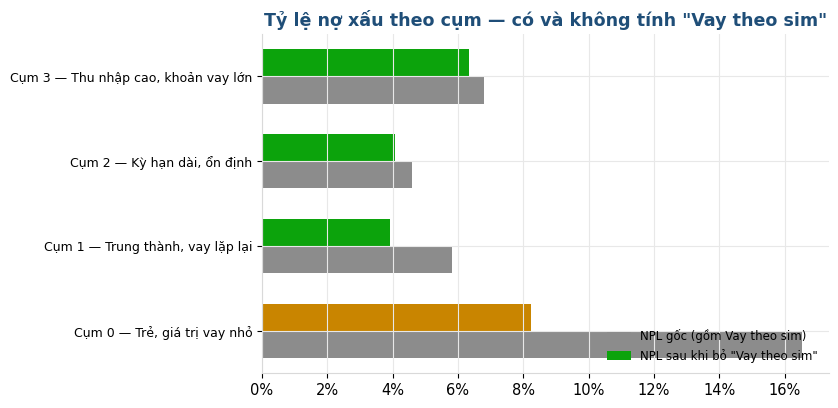

Số khách BỊ LOẠI khỏi so sánh (toàn bộ lịch sử vay chỉ có "Vay theo sim"): 245

=== So sánh NPL theo cụm: gốc vs. sau khi bỏ 'Vay theo sim' (số liệu của lần chạy này) ===
- Thu nhập cao, khoản vay lớn: 6.8% -> 6.3%  (n sau khi loại = 474)
- Kỳ hạn dài, ổn định: 4.6% -> 4.1%  (n sau khi loại = 344)
- Trung thành, vay lặp lại: 5.8% -> 3.9%  (n sau khi loại = 102)
- Trẻ, giá trị vay nhỏ: 16.5% -> 8.3%  (n sau khi loại = 703)

-> Cụm rủi ro CAO NHẤT không đổi sau khi loại 'Vay theo sim': vẫn là 'Trẻ, giá trị vay nhỏ' — kết luận cốt lõi ở mục 3-4 không phải hệ quả của riêng một sản phẩm, mà phản ánh đúng đặc điểm hành vi của nhóm khách hàng này.
   (Thứ hạng có xáo trộn nhẹ ở các cụm rủi ro thấp hơn — các cụm này vốn có NPL khá gần nhau nên dễ đổi chỗ; không ảnh hưởng đến kết luận về nhóm rủi ro cao nhất ở trên.)


In [ ]:
# ===== Tính lại "tung_no_xau" sau khi loại toàn bộ khoản vay "Vay theo sim" =====
df_khong_sim = df_sorted[df_sorted["ProductCreditName"] != "Vay theo sim"]
tung_no_xau_khong_sim = df_khong_sim.groupby("CardNumber")["Trạng thái"].apply(lambda s: (s == "Nợ Xấu").any())

# Khách mà TOÀN BỘ lịch sử vay chỉ là "Vay theo sim" sẽ không còn dòng nào trong df_khong_sim
# -> không có giá trị tung_no_xau_khong_sim -> phải loại khỏi so sánh, không thể gán "không nợ xấu".
co_khoan_khong_sim = df_c["CardNumber"].isin(tung_no_xau_khong_sim.index)
so_khach_bi_loai = int((~co_khoan_khong_sim).sum())
df_c["tung_no_xau_khong_sim"] = df_c["CardNumber"].map(tung_no_xau_khong_sim)

npl_khong_sim = df_c.groupby("Cum")["tung_no_xau_khong_sim"].mean()   # mean() tự bỏ qua NaN
n_khong_sim = df_c.groupby("Cum")["tung_no_xau_khong_sim"].count()

so_sanh = npl_cum[["ty_le_no_xau"]].rename(columns={"ty_le_no_xau": "NPL_goc"})
so_sanh["NPL_bo_sim"] = npl_khong_sim
so_sanh["n_bo_sim"] = n_khong_sim
so_sanh = so_sanh.reindex(sorted(TEN_CUM, reverse=True))  # đảo để Cụm 0 hiện trên cùng sau invert_yaxis

# ===== Biểu đồ: 2 cột ngang / cụm — NPL gốc (xám, mức tham chiếu) vs NPL sau khi bỏ "Vay theo sim" =====
fig, ax = plt.subplots(figsize=(8.5, 4.2))
y_pos = np.arange(len(so_sanh))
h = 0.32

ax.barh(y_pos + h / 2, so_sanh["NPL_goc"] * 100, height=h, color=GRAY, label="NPL gốc (gồm Vay theo sim)")
mau_bo_sim = [BAD if v >= 0.15 else (WARN if v >= 0.08 else GOOD) for v in so_sanh["NPL_bo_sim"]]
ax.barh(y_pos - h / 2, so_sanh["NPL_bo_sim"] * 100, height=h, color=mau_bo_sim,
        label='NPL sau khi bỏ "Vay theo sim"')

ax.set_yticks(y_pos)
ax.set_yticklabels([f"Cụm {c} — {TEN_CUM[c]}" for c in so_sanh.index])
ax.invert_yaxis()
ax.set_title('Tỷ lệ nợ xấu theo cụm — có và không tính "Vay theo sim"')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
ax.tick_params(axis="y", labelsize=9)
ax.legend(loc="lower right", fontsize=8.5, frameon=False)
plt.tight_layout()
plt.show()

print(f'Số khách BỊ LOẠI khỏi so sánh (toàn bộ lịch sử vay chỉ có "Vay theo sim"): {so_khach_bi_loai}')
print()
print("=== So sánh NPL theo cụm: gốc vs. sau khi bỏ 'Vay theo sim' (số liệu của lần chạy này) ===")
for c in so_sanh.index:
    r = so_sanh.loc[c]
    print(f"- {TEN_CUM[c]}: {r['NPL_goc']:.1%} -> {r['NPL_bo_sim']:.1%}  (n sau khi loại = {r['n_bo_sim']:.0f})")

thu_hang_goc = so_sanh["NPL_goc"].rank(ascending=False)
thu_hang_bo_sim = so_sanh["NPL_bo_sim"].rank(ascending=False)

# Câu hỏi kinh doanh cốt lõi ở mục 3-4 là "cụm nào rủi ro CAO NHẤT" -> kiểm tra riêng điều này,
# tách khỏi việc xáo trộn thứ hạng ở các cụm rủi ro thấp hơn (vốn có NPL khá gần nhau, dễ đổi chỗ).
cum_cao_nhat_goc = so_sanh["NPL_goc"].idxmax()
cum_cao_nhat_bo_sim = so_sanh["NPL_bo_sim"].idxmax()
if cum_cao_nhat_goc == cum_cao_nhat_bo_sim:
    print(f"\n-> Cụm rủi ro CAO NHẤT không đổi sau khi loại 'Vay theo sim': vẫn là "
          f"'{TEN_CUM[cum_cao_nhat_goc]}' — kết luận cốt lõi ở mục 3-4 không phải hệ quả của riêng "
          "một sản phẩm, mà phản ánh đúng đặc điểm hành vi của nhóm khách hàng này.")
else:
    print(f"\n-> Cụm rủi ro CAO NHẤT đổi từ '{TEN_CUM[cum_cao_nhat_goc]}' sang "
          f"'{TEN_CUM[cum_cao_nhat_bo_sim]}' sau khi loại 'Vay theo sim' — cần xem lại kết luận "
          "ở mục 3-4 vì có thể đang phụ thuộc vào riêng sản phẩm này.")

if not thu_hang_goc.equals(thu_hang_bo_sim):
    print("   (Thứ hạng có xáo trộn nhẹ ở các cụm rủi ro thấp hơn — các cụm này vốn có NPL khá gần "
          "nhau nên dễ đổi chỗ; không ảnh hưởng đến kết luận về nhóm rủi ro cao nhất ở trên.)")


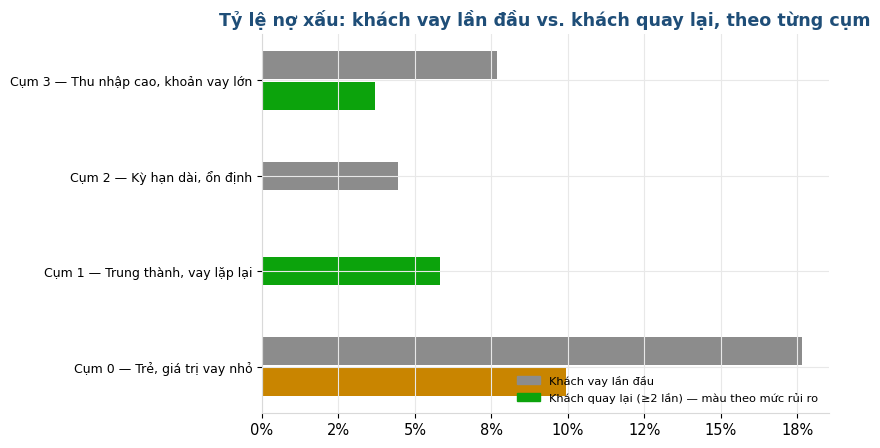

Bỏ qua do n < 15:
  - Kỳ hạn dài, ổn định / Khách quay lại (≥2 lần) (n=12)

So sánh khách quay lại vs. khách vay lần đầu trong từng cụm (số liệu của lần chạy này):
- Thu nhập cao, khoản vay lớn: lần đầu 7.7% -> quay lại 3.7% (thấp hơn)
- Kỳ hạn dài, ổn định: cụm này gần như chỉ gồm khách quay lại (đúng theo đặc điểm dùng để đặt tên cụm) — không đủ khách vay lần đầu (n>=15) để so sánh trong nội bộ cụm.
- Trung thành, vay lặp lại: cụm này gần như chỉ gồm khách quay lại (đúng theo đặc điểm dùng để đặt tên cụm) — không đủ khách vay lần đầu (n>=15) để so sánh trong nội bộ cụm.
- Trẻ, giá trị vay nhỏ: lần đầu 17.6% -> quay lại 9.9% (thấp hơn)


In [ ]:
# ===== NPL: khách vay lần đầu vs. khách quay lại (>=2 lần), cắt theo từng cụm =====
df_c["quay_lai"] = np.where(df_c["so_lan_vay"] >= 2, "Khách quay lại (≥2 lần)", "Khách vay lần đầu")

bang_quaylai = df_c.groupby(["Cum", "quay_lai"])["tung_no_xau"].agg(n="count", ty_le_no_xau="mean").reset_index()
bang_quaylai_du_lon = bang_quaylai[bang_quaylai["n"] >= 15].copy()  # cùng ngưỡng n>=15 dùng xuyên suốt notebook

nhom_thu_tu = ["Khách vay lần đầu", "Khách quay lại (≥2 lần)"]
cum_list = [c for c in sorted(TEN_CUM, reverse=True) if c in bang_quaylai_du_lon["Cum"].unique()]

# Cột ngang, nhóm CỤC BỘ theo từng cụm — chỉ vẽ nhóm khách thực sự có đủ dữ liệu (n>=15) trong cụm đó,
# tránh để trống chỗ cho nhóm không đủ dữ liệu (cùng kỹ thuật đã dùng ở biểu đồ năm x sản phẩm, mục 2).
fig, ax = plt.subplots(figsize=(8.5, 4.6))
h = 0.32
labels_cum = []
for idx, c in enumerate(cum_list):
    hang = bang_quaylai_du_lon[bang_quaylai_du_lon["Cum"] == c].set_index("quay_lai")
    nhom_o_cum = [g for g in nhom_thu_tu if g in hang.index]
    k = len(nhom_o_cum)
    for j, nhom in enumerate(nhom_o_cum):
        ypos = idx + h * (j - (k - 1) / 2)
        gia_tri = hang.loc[nhom, "ty_le_no_xau"] * 100
        # "Khách vay lần đầu" luôn vẽ màu xám làm mức nền tham chiếu; "Khách quay lại" tô theo mức rủi ro
        # (cùng ngưỡng BAD/WARN/GOOD đã dùng ở biểu đồ NPL theo cụm, mục 3) để nêu bật phần đang so sánh.
        if nhom == "Khách vay lần đầu":
            mau = GRAY
        else:
            mau = BAD if gia_tri / 100 >= 0.15 else (WARN if gia_tri / 100 >= 0.08 else GOOD)
        ax.barh(ypos, gia_tri, height=h * 0.92, color=mau)
    labels_cum.append(f"Cụm {c} — {TEN_CUM[c]}")

ax.set_yticks(range(len(cum_list)))
ax.set_yticklabels(labels_cum)
ax.invert_yaxis()
ax.set_title("Tỷ lệ nợ xấu: khách vay lần đầu vs. khách quay lại, theo từng cụm")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
ax.tick_params(axis="y", labelsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GRAY, label="Khách vay lần đầu"),
                    Patch(color=GOOD, label="Khách quay lại (≥2 lần) — màu theo mức rủi ro")],
          fontsize=8.2, frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

bo_qua = bang_quaylai[bang_quaylai["n"] < 15]
if len(bo_qua):
    print("Bỏ qua do n < 15:")
    for _, r in bo_qua.sort_values("Cum").iterrows():
        print(f"  - {TEN_CUM[r['Cum']]} / {r['quay_lai']} (n={int(r['n'])})")
    print()

print("So sánh khách quay lại vs. khách vay lần đầu trong từng cụm (số liệu của lần chạy này):")
for c in cum_list:
    hang = bang_quaylai_du_lon[bang_quaylai_du_lon["Cum"] == c].set_index("quay_lai")
    co_ca_hai = "Khách vay lần đầu" in hang.index and "Khách quay lại (≥2 lần)" in hang.index
    if co_ca_hai:
        lan_dau = hang.loc["Khách vay lần đầu", "ty_le_no_xau"]
        quay_lai = hang.loc["Khách quay lại (≥2 lần)", "ty_le_no_xau"]
        huong = "thấp hơn" if quay_lai < lan_dau else "KHÔNG thấp hơn"
        print(f"- {TEN_CUM[c]}: lần đầu {lan_dau:.1%} -> quay lại {quay_lai:.1%} ({huong})")
    else:
        print(f"- {TEN_CUM[c]}: cụm này gần như chỉ gồm khách quay lại (đúng theo đặc điểm dùng để đặt "
              "tên cụm) — không đủ khách vay lần đầu (n>=15) để so sánh trong nội bộ cụm.")


**Bổ sung — Kiểm tra hiệu quả của điểm tín dụng nội bộ (TS_CREDIT_SCORE_V2)**

Báo cáo đánh giá dự án (giai đoạn EDA) đã chỉ ra cột `TS_CREDIT_SCORE_V2` — điểm tín dụng nội bộ
TIMA tự chấm cho từng khoản vay (thang 300–826, giống thang FICO) — có sẵn trong dữ liệu nhưng
chưa được đưa vào phân tích. Câu hỏi cần trả lời: điểm này có thực sự tách biệt được khách hàng
rủi ro cao/thấp không? Thước đo chuẩn ngành cho bài toán này là **ROC-AUC** (diện tích dưới đường
ROC, dùng `sklearn.metrics.roc_auc_score`): AUC = 0,5 nghĩa là điểm không hơn gì đoán ngẫu nhiên,
AUC càng gần 1 thì điểm càng phân biệt tốt khách tốt/xấu. Đi kèm 2 chỉ số bổ trợ chuẩn trong ngành
tín dụng: **Gini = 2×AUC − 1** và **KS (Kolmogorov–Smirnov)** — đo khoảng cách lớn nhất giữa phân
phối TPR và FPR.

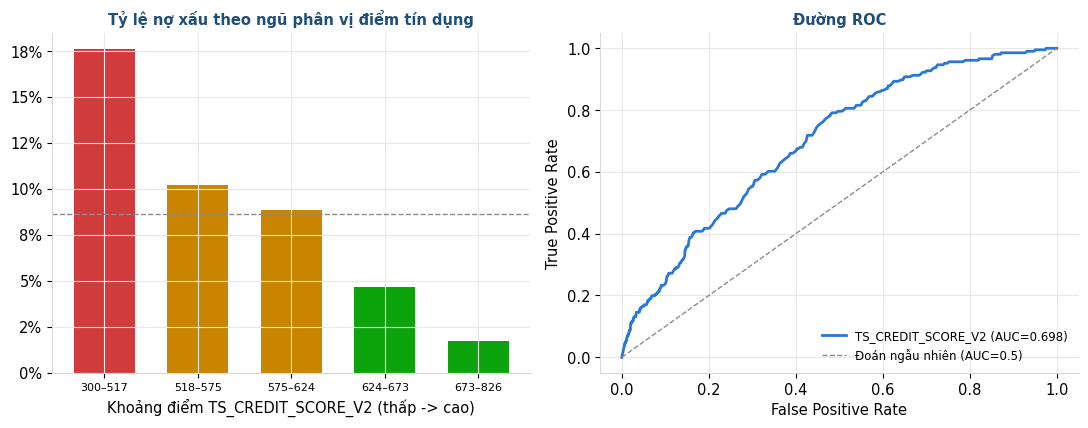

AUC = 0.698  |  Gini = 0.395  |  KS = 0.308
Tỷ lệ nợ xấu chung (đường tham chiếu, nét đứt): 8.6%

-> Theo thang đánh giá mô hình tín dụng chuẩn ngành (AUC<0.65 kém / 0.65–0.75 chấp nhận được / ≥0.75 tốt): CHẤP NHẬN ĐƯỢC — phù hợp chuẩn vay tiêu dùng tín chấp/bán bảo đảm.
   Tỷ lệ nợ xấu giảm khá đều đặn qua các ngũ phân vị điểm — điểm số có tín hiệu thật, không chỉ là con số trang trí trong hồ sơ.


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

y_no_xau = (df["Trạng thái"] == "Nợ Xấu").astype(int)
# TS_CREDIT_SCORE_V2 càng CAO thì càng AN TOÀN (giống thang FICO) -> roc_auc_score cần một "điểm
# rủi ro" tăng dần theo xác suất nợ xấu, nên dùng -TS_CREDIT_SCORE_V2 làm y_score.
diem_rui_ro = -df["TS_CREDIT_SCORE_V2"]

auc = roc_auc_score(y_no_xau, diem_rui_ro)
gini = 2 * auc - 1
fpr, tpr, _ = roc_curve(y_no_xau, diem_rui_ro)
ks = (tpr - fpr).max()

# Small-multiple: NPL theo ngũ phân vị điểm (trái, dễ đọc cho người không rành ROC) + đường ROC (phải)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

ngu_phan_vi = pd.qcut(df["TS_CREDIT_SCORE_V2"], 5)
npl_theo_diem = y_no_xau.groupby(ngu_phan_vi, observed=True).mean()
nhan_ngu_phan_vi = [f"{int(np.ceil(b.left))}–{int(b.right)}" for b in npl_theo_diem.index]
mau_ngu_phan_vi = [BAD if v >= 0.15 else (WARN if v >= 0.08 else GOOD) for v in npl_theo_diem]
axes[0].bar(nhan_ngu_phan_vi, npl_theo_diem * 100, color=mau_ngu_phan_vi, width=0.65)
axes[0].axhline(y_no_xau.mean() * 100, color=GRAY, linestyle="--", linewidth=1)
axes[0].set_title("Tỷ lệ nợ xấu theo ngũ phân vị điểm tín dụng", fontsize=10.5)
axes[0].set_xlabel("Khoảng điểm TS_CREDIT_SCORE_V2 (thấp -> cao)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
axes[0].tick_params(axis="x", labelsize=8)

axes[1].plot(fpr, tpr, color=BLUE, linewidth=2, label=f"TS_CREDIT_SCORE_V2 (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1, label="Đoán ngẫu nhiên (AUC=0.5)")
axes[1].set_title("Đường ROC", fontsize=10.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8.5, frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

print(f"AUC = {auc:.3f}  |  Gini = {gini:.3f}  |  KS = {ks:.3f}")
print(f"Tỷ lệ nợ xấu chung (đường tham chiếu, nét đứt): {y_no_xau.mean():.1%}")
print()
if auc >= 0.75:
    muc = "TỐT — đủ tiêu chuẩn đưa vào hệ thống chấm điểm tự động"
elif auc >= 0.65:
    muc = "CHẤP NHẬN ĐƯỢC — phù hợp chuẩn vay tiêu dùng tín chấp/bán bảo đảm"
else:
    muc = "KÉM — chưa nên dùng độc lập cho thẩm định"
print(f"-> Theo thang đánh giá mô hình tín dụng chuẩn ngành "
      f"(AUC<0.65 kém / 0.65–0.75 chấp nhận được / ≥0.75 tốt): {muc}.")
print("   Tỷ lệ nợ xấu giảm khá đều đặn qua các ngũ phân vị điểm — điểm số có tín hiệu thật, "
      "không chỉ là con số trang trí trong hồ sơ.")


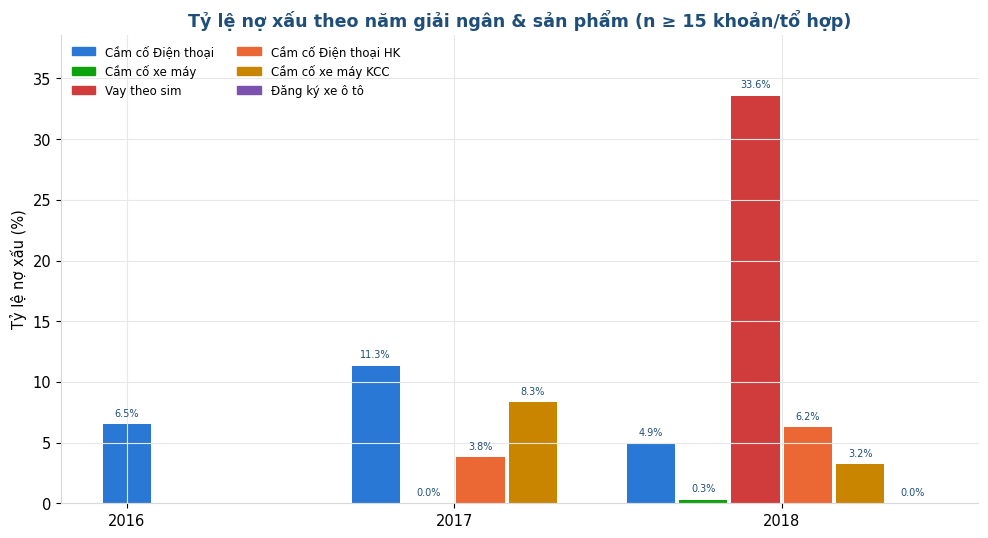

Bỏ qua vì n < 15:
- 2017 · Đăng ký xe ô tô (n=7)
- 2017 · Ô tô ngân hàng (n=1)
- 2018 · Ô tô ngân hàng (n=7)
- 2018 · Vay trực tuyến qua Sim (n=5)
- 2018 · Cầm Sim Số Đẹp (n=3)
- 2018 · Cầm ô tô (n=1)


In [ ]:
# Loại năm 2019 vì chỉ có 5 khoản (tháng 1/2019, xem mục 6) -> không đủ dữ liệu, dễ gây hiểu nhầm
df_nam_sp = df[df["nam_vay"] != 2019].copy()

bang_nam_sp = df_nam_sp.groupby(["nam_vay", "ProductCreditName"]).agg(
    n=("LoanID", "count"),
    no_xau=("Trạng thái", lambda s: (s == "Nợ Xấu").sum()),
).reset_index()
bang_nam_sp["ty_le_no_xau"] = bang_nam_sp["no_xau"] / bang_nam_sp["n"]

# Chỉ vẽ tổ hợp (năm, sản phẩm) đủ dữ liệu (n >= 15, cùng ngưỡng đã dùng ở mục 3 khu vực / mục 5 nghề nghiệp)
bang_nam_sp_du_lon = bang_nam_sp[bang_nam_sp["n"] >= 15].copy()

volume_order = df["ProductCreditName"].value_counts().index.tolist()
san_pham_hien = [sp for sp in volume_order if sp in bang_nam_sp_du_lon["ProductCreditName"].unique()]

# Thêm PURPLE cục bộ cho sản phẩm thứ 6 (không đưa vào bảng màu dùng chung ở đầu Phần 2)
PURPLE = "#7B52AE"
mau_sp = {
    "Cầm cố Điện thoại": BLUE, "Cầm cố xe máy": GOOD, "Vay theo sim": BAD,
    "Cầm cố Điện thoại HK": ORANGE, "Cầm cố xe máy KCC": WARN, "Đăng ký xe ô tô": PURPLE,
}

# Vẽ cột nhóm theo TỪNG NĂM: chỉ xếp các sản phẩm THỰC SỰ có dữ liệu đủ lớn trong năm đó, xếp sát
# nhau và căn giữa dưới nhãn năm -> tránh để trống chỗ cho sản phẩm không tồn tại trong năm đó
# (vd. "Vay theo sim" chỉ ra mắt từ 2018 nên không chiếm chỗ ở nhóm cột 2016/2017).
nam_list = sorted(bang_nam_sp_du_lon["nam_vay"].unique())
fig, ax = plt.subplots(figsize=(10, 5.5))
w = 0.16
gia_tri_max = (bang_nam_sp_du_lon["ty_le_no_xau"] * 100).max()  # để chừa khoảng trống phía trên cho nhãn số
for idx, nam in enumerate(nam_list):
    hang = bang_nam_sp_du_lon[bang_nam_sp_du_lon["nam_vay"] == nam].set_index("ProductCreditName")
    sp_nam = [sp for sp in san_pham_hien if sp in hang.index]
    k = len(sp_nam)
    for j, sp in enumerate(sp_nam):
        xpos = idx + w * (j - (k - 1) / 2)
        gia_tri = hang.loc[sp, "ty_le_no_xau"] * 100
        ax.bar(xpos, gia_tri, width=w * 0.92, color=mau_sp.get(sp, GRAY))
        # Nhãn tỷ lệ nợ xấu chi tiết trên đầu mỗi cột
        ax.text(xpos, gia_tri + gia_tri_max * 0.015, f"{gia_tri:.1f}%",
                ha="center", va="bottom", fontsize=7, color=NAVY)

ax.set_xticks(range(len(nam_list)))
ax.set_xticklabels(nam_list)
ax.set_ylabel("Tỷ lệ nợ xấu (%)")
ax.set_title("Tỷ lệ nợ xấu theo năm giải ngân & sản phẩm (n ≥ 15 khoản/tổ hợp)")
ax.set_ylim(0, gia_tri_max * 1.15)  # chừa chỗ cho nhãn của cột cao nhất, tránh bị cắt ở mép trên

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=mau_sp[sp], label=sp) for sp in san_pham_hien],
          fontsize=8.5, frameon=False, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()

print("Bỏ qua vì n < 15:")
for _, r in bang_nam_sp[bang_nam_sp["n"] < 15].sort_values(["nam_vay", "n"], ascending=[True, False]).iterrows():
    print(f"- {int(r['nam_vay'])} · {r['ProductCreditName']} (n={int(r['n'])})")

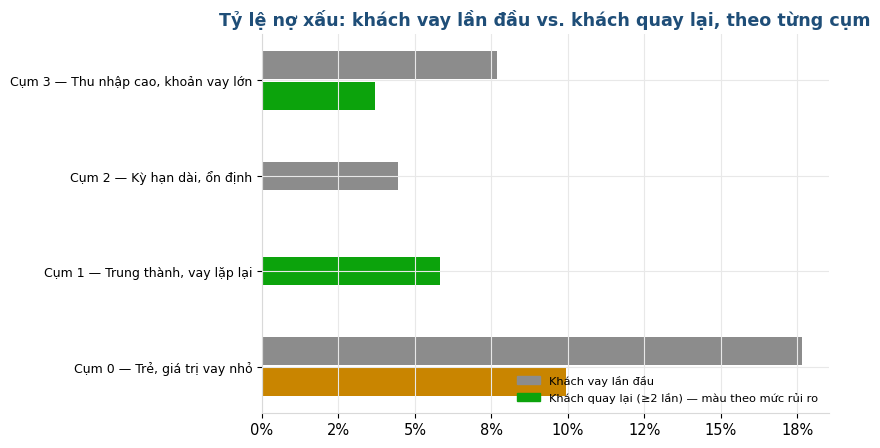

Bỏ qua do n < 15:
  - Kỳ hạn dài, ổn định / Khách quay lại (≥2 lần) (n=12)

So sánh khách quay lại vs. khách vay lần đầu trong từng cụm (số liệu của lần chạy này):
- Thu nhập cao, khoản vay lớn: lần đầu 7.7% -> quay lại 3.7% (thấp hơn)
- Kỳ hạn dài, ổn định: cụm này chủ yếu là khách vay lần đầu — số khách quay lại quá ít (n<15) để so sánh đáng tin cậy trong nội bộ cụm.
- Trung thành, vay lặp lại: cụm này gần như chỉ gồm khách quay lại — không đủ khách vay lần đầu (n>=15) để so sánh trong nội bộ cụm.
- Trẻ, giá trị vay nhỏ: lần đầu 17.6% -> quay lại 9.9% (thấp hơn)


In [ ]:
# ===== NPL: khách vay lần đầu vs. khách quay lại (>=2 lần), cắt theo từng cụm =====
df_c["quay_lai"] = np.where(df_c["so_lan_vay"] >= 2, "Khách quay lại (≥2 lần)", "Khách vay lần đầu")

bang_quaylai = df_c.groupby(["Cum", "quay_lai"])["tung_no_xau"].agg(n="count", ty_le_no_xau="mean").reset_index()
bang_quaylai_du_lon = bang_quaylai[bang_quaylai["n"] >= 15].copy()  # cùng ngưỡng n>=15 dùng xuyên suốt notebook

nhom_thu_tu = ["Khách vay lần đầu", "Khách quay lại (≥2 lần)"]
cum_list = [c for c in sorted(TEN_CUM, reverse=True) if c in bang_quaylai_du_lon["Cum"].unique()]

# Cột ngang, nhóm CỤC BỘ theo từng cụm — chỉ vẽ nhóm khách thực sự có đủ dữ liệu (n>=15) trong cụm đó,
# tránh để trống chỗ cho nhóm không đủ dữ liệu (cùng kỹ thuật đã dùng ở biểu đồ năm x sản phẩm, mục 2).
fig, ax = plt.subplots(figsize=(8.5, 4.6))
h = 0.32
labels_cum = []
for idx, c in enumerate(cum_list):
    hang = bang_quaylai_du_lon[bang_quaylai_du_lon["Cum"] == c].set_index("quay_lai")
    nhom_o_cum = [g for g in nhom_thu_tu if g in hang.index]
    k = len(nhom_o_cum)
    for j, nhom in enumerate(nhom_o_cum):
        ypos = idx + h * (j - (k - 1) / 2)
        gia_tri = hang.loc[nhom, "ty_le_no_xau"] * 100
        # "Khách vay lần đầu" luôn vẽ màu xám làm mức nền tham chiếu; "Khách quay lại" tô theo mức rủi ro
        # (cùng ngưỡng BAD/WARN/GOOD đã dùng ở biểu đồ NPL theo cụm, mục 3) để nêu bật phần đang so sánh.
        if nhom == "Khách vay lần đầu":
            mau = GRAY
        else:
            mau = BAD if gia_tri / 100 >= 0.15 else (WARN if gia_tri / 100 >= 0.08 else GOOD)
        ax.barh(ypos, gia_tri, height=h * 0.92, color=mau)
    labels_cum.append(f"Cụm {c} — {TEN_CUM[c]}")

ax.set_yticks(range(len(cum_list)))
ax.set_yticklabels(labels_cum)
ax.invert_yaxis()
ax.set_title("Tỷ lệ nợ xấu: khách vay lần đầu vs. khách quay lại, theo từng cụm")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
ax.tick_params(axis="y", labelsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GRAY, label="Khách vay lần đầu"),
                    Patch(color=GOOD, label="Khách quay lại (≥2 lần) — màu theo mức rủi ro")],
          fontsize=8.2, frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

bo_qua = bang_quaylai[bang_quaylai["n"] < 15]
if len(bo_qua):
    print("Bỏ qua do n < 15:")
    for _, r in bo_qua.sort_values("Cum").iterrows():
        print(f"  - {TEN_CUM[r['Cum']]} / {r['quay_lai']} (n={int(r['n'])})")
    print()

print("So sánh khách quay lại vs. khách vay lần đầu trong từng cụm (số liệu của lần chạy này):")
for c in cum_list:
    hang = bang_quaylai_du_lon[bang_quaylai_du_lon["Cum"] == c].set_index("quay_lai")
    co_lan_dau = "Khách vay lần đầu" in hang.index
    co_quay_lai = "Khách quay lại (≥2 lần)" in hang.index
    if co_lan_dau and co_quay_lai:
        lan_dau = hang.loc["Khách vay lần đầu", "ty_le_no_xau"]
        quay_lai = hang.loc["Khách quay lại (≥2 lần)", "ty_le_no_xau"]
        huong = "thấp hơn" if quay_lai < lan_dau else "KHÔNG thấp hơn"
        print(f"- {TEN_CUM[c]}: lần đầu {lan_dau:.1%} -> quay lại {quay_lai:.1%} ({huong})")
    elif co_quay_lai and not co_lan_dau:
        # Cụm gần như chỉ gồm khách quay lại (vd. "Trung thành, vay lặp lại" -- đúng theo đặc điểm dùng
        # để đặt tên cụm) -> không đủ khách vay lần đầu (n>=15) để so sánh trong nội bộ cụm.
        print(f"- {TEN_CUM[c]}: cụm này gần như chỉ gồm khách quay lại — không đủ khách vay lần đầu "
              "(n>=15) để so sánh trong nội bộ cụm.")
    elif co_lan_dau and not co_quay_lai:
        # Chiều ngược lại (vd. "Kỳ hạn dài, ổn định"): cụm chủ yếu là khách vay lần đầu, số khách quay
        # lại quá ít (n<15) để so sánh đáng tin cậy -- KHÔNG được nhầm với trường hợp trên.
        print(f"- {TEN_CUM[c]}: cụm này chủ yếu là khách vay lần đầu — số khách quay lại quá ít (n<15) "
              "để so sánh đáng tin cậy trong nội bộ cụm.")
    else:
        print(f"- {TEN_CUM[c]}: không đủ dữ liệu (n>=15) ở cả 2 nhóm để so sánh trong cụm này.")


In [ ]:
# =====================================================================
# KIỂM TRA BỔ SUNG CHO BUỔI BẢO VỆ — dán vào 1 ô MỚI ở CUỐI notebook
# (chạy sau khi đã chạy hết các ô phía trên, cần sẵn: df, df_c, dist, km, X_scaled)
# =====================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from statsmodels.stats.proportion import proportion_confint

NGAY_CHOT = df["FromDate"].max()                       # 18/01/2019 — ngày cuối của dữ liệu
df["da_dao_han"] = df["ToDate"] <= NGAY_CHOT           # khoản vay đã đến hạn trước khi dữ liệu dừng
df["no_xau"] = (df["Trạng thái"] == "Nợ Xấu").astype(int)
df["TenCum"] = df["CardNumber"].map(df_c.set_index("CardNumber")["TenCum"])

# ---------- Câu 1, 9, 11: ĐỘ CHÍN ----------
print("=== 1) Trạng thái khoản vay theo năm giải ngân (tỷ lệ theo dòng) ===")
print(pd.crosstab(df["nam_vay"], df["Trạng thái"], normalize="index").round(3))

print("\n=== 2) Theo cụm: % khoản CHƯA đáo hạn, % còn 'Đang Vay', NPL (mức khoản vay) ===")
print(df.groupby("TenCum").agg(
    so_khoan=("LoanID", "count"),
    pct_chua_dao_han=("da_dao_han", lambda s: 1 - s.mean()),
    pct_dang_vay=("Trạng thái", lambda s: (s == "Đang Vay").mean()),
    npl_tat_ca=("no_xau", "mean"),
).round(3))

print("\n=== 3) NPL theo cụm — CHỈ tính khoản ĐÃ đáo hạn ===")
print(df[df["da_dao_han"]].groupby("TenCum").agg(
    so_khoan=("LoanID", "count"), npl=("no_xau", "mean")).round(3))

print("\n=== 4) NPL theo năm × sản phẩm — CHỈ tính khoản ĐÃ đáo hạn (câu 9) ===")
m = df[df["da_dao_han"] & df["ProductCreditName"].isin(["Cầm cố Điện thoại", "Vay theo sim"])]
print(m.groupby(["nam_vay", "ProductCreditName"]).agg(
    so_khoan=("LoanID", "count"), npl=("no_xau", "mean")).round(3))

print("\n=== 5) Khách lần đầu vs quay lại — CHỈ tính khoản ĐÃ đáo hạn (câu 11) ===")
print(df[df["da_dao_han"]].groupby("nhom_khach").agg(
    so_khoan=("LoanID", "count"), npl=("no_xau", "mean")).round(3))

# ---------- Câu 6, 23: QUẬN ----------
print("\n=== 6) Quận n>=15: khoảng tin cậy 95% (Wilson) ===")
d = dist[dist["n"] >= 15].copy()
d["ci_duoi"], d["ci_tren"] = proportion_confint(d["no_xau"], d["n"], method="wilson")
d["cao_hon_nen_chac_chan"] = d["ci_duoi"] > df["no_xau"].mean()
print("Số quận đạt n>=15:", len(d))
print(d.sort_values("ty_le_no_xau", ascending=False).round(3).to_string())

# ---------- Câu 15, 10: HÀ NỘI vs TP.HCM + doanh số theo quận ----------
print("\n=== 7) Hà Nội vs TP.HCM ===")
print(df.groupby("CityName").agg(
    so_khoan=("LoanID", "count"), giai_ngan_ty=("Tiền giải ngân", lambda s: s.sum() / 1e9),
    npl=("no_xau", "mean")).sort_values("so_khoan", ascending=False).head(2).round(3))

print("\n=== 8) Top 10 quận theo giải ngân ===")
print(df.groupby(["CityName", "DistrictName"]).agg(
    so_khoan=("LoanID", "count"), giai_ngan_ty=("Tiền giải ngân", lambda s: s.sum() / 1e9),
    npl=("no_xau", "mean")).sort_values("giai_ngan_ty", ascending=False).head(10).round(3))

# ---------- Câu 17: KIỂM LẠI SỐ LIỆU ĐỀ XUẤT 1 ----------
print("\n=== 9) Đề xuất 1: chặn Vay theo sim × cụm Trẻ ===")
chan = (df["ProductCreditName"] == "Vay theo sim") & (df["TenCum"] == "Trẻ, giá trị vay nhỏ")
print("Số khoản bị chặn:", chan.sum(), "| trong đó nợ xấu:", df.loc[chan, "no_xau"].sum(),
      "| NPL tổ hợp:", round(df.loc[chan, "no_xau"].mean(), 3))
print("Tỷ trọng số khoản:", round(chan.mean(), 3),
      "| Tỷ trọng giải ngân:", round(df.loc[chan, "Tiền giải ngân"].sum() / df["Tiền giải ngân"].sum(), 3))
print("NPL còn lại sau khi chặn:", round(df.loc[~chan, "no_xau"].mean(), 4))

# ---------- Câu 2: PHÂN CỤM LẠI KHÔNG DÙNG 'so_lan_vay' ----------
print("\n=== 10) Phân cụm lại KHÔNG có so_lan_vay — so với cụm gốc ===")
X2 = StandardScaler().fit_transform(df_c[["log_giai_ngan", "Age", "ky_han_ngay_tb", "Salary"]])
km2 = KMeans(n_clusters=4, random_state=42, n_init=50).fit(X2)
print(pd.crosstab(df_c["TenCum"], km2.labels_))
print("ARI giữa 2 cách phân cụm:", round(adjusted_rand_score(df_c["Cum"], km2.labels_), 3))

# ---------- Câu 4: ĐỘ ỔN ĐỊNH CỦA CỤM ----------
print("\n=== 11) Độ ổn định: phân cụm trên 20 mẫu con 80% ===")
rng = np.random.default_rng(0)
aris = []
for i in range(20):
    idx = rng.choice(len(X_scaled), int(0.8 * len(X_scaled)), replace=False)
    km_b = KMeans(n_clusters=4, random_state=i, n_init=10).fit(X_scaled[idx])
    aris.append(adjusted_rand_score(km.labels_, km_b.predict(X_scaled)))
print(f"ARI trung bình = {np.mean(aris):.3f} | thấp nhất = {np.min(aris):.3f}  (>0.8 là ổn định tốt)")

# ---------- Câu 5: LƯƠNG CÓ NGOẠI LAI KHÔNG ----------
print("\n=== 12) Phân phối lương theo cụm ===")
print(df_c.groupby("TenCum")["Salary"].describe(percentiles=[.5, .9, .99]).round(-5))


=== 1) Trạng thái khoản vay theo năm giải ngân (tỷ lệ theo dòng) ===
Trạng thái  Kết thúc  Nợ Xấu  Đang Vay
nam_vay                               
2016           0.935   0.065     0.000
2017           0.899   0.076     0.025
2018           0.523   0.094     0.383
2019           0.600   0.000     0.400

=== 2) Theo cụm: % khoản CHƯA đáo hạn, % còn 'Đang Vay', NPL (mức khoản vay) ===
                             so_khoan  pct_chua_dao_han  pct_dang_vay  npl_tat_ca
TenCum                                                                           
Kỳ hạn dài, ổn định               383             0.791         0.668       0.044
Thu nhập cao, khoản vay lớn       594             0.328         0.247       0.056
Trung thành, vay lặp lại          367             0.139         0.093       0.016
Trẻ, giá trị vay nhỏ             1039             0.218         0.147       0.144

=== 3) NPL theo cụm — CHỈ tính khoản ĐÃ đáo hạn ===
                             so_khoan    npl
TenCum                   

In [ ]:
print(f"Tổng số dư nợ (Số tiền còn lại): {df['SoTienConLai'].sum():,.0f}")

Tổng số dư nợ (Số tiền còn lại): 10,580,029,715


In [ ]:
# ============================================================
# B1 — Xem đầy đủ các giá trị của cột Trạng thái, theo năm giải ngân
# ============================================================
print("Tổng số khoản theo Trạng thái (toàn danh mục):")
print(df["Trạng thái"].value_counts(dropna=False))

print("\nSố khoản vay theo năm giải ngân × Trạng thái:")
bang_trangthai = pd.crosstab(df["nam_vay"], df["Trạng thái"], margins=True, margins_name="Tổng")
print(bang_trangthai)

Tổng số khoản theo Trạng thái (toàn danh mục):
Trạng thái
Kết thúc    1587
Đang Vay     590
Nợ Xấu       206
Name: count, dtype: int64

Số khoản vay theo năm giải ngân × Trạng thái:
Trạng thái  Kết thúc  Nợ Xấu  Đang Vay  Tổng
nam_vay                                     
2016             130       9         0   139
2017             676      57        19   752
2018             778     140       569  1487
2019               3       0         2     5
Tổng            1587     206       590  2383
